# config dan library

In [1]:
import pandas as pd
from IPython.display import display, HTML
from matplotlib.patches import Patch
import numpy as np

print("LIBRARY OK")

LIBRARY OK


In [2]:
import matplotlib.pyplot as plt

COLOR_MAIN   = "#D9D9D9"   # violin/histogram
COLOR_SECOND = "#6E6E6E"   # mean
COLOR_ACCENT = "#3E3E3E"   # median/regression
COLOR_DOT    = "#7A7A7A"   # scatter/swarm
COLOR_BORDER = "#8A8A8A"   # outline
COLOR_GRID   = "#DADADA"   # grid

FIGSIZE = (6.5, 4.5)
DPI = 600

plt.rcParams.update({

    # Font
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,

    # Titles
    "axes.titlesize": 11,
    "axes.labelsize": 10,

    # Tick Labels
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Legend
    "legend.fontsize": 9,

    # Figure
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "figure.facecolor": "white",

    # Axes
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,

    # Grid
    "axes.grid": True,
    "grid.color": "#D0D0D0",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.6,

    # Spines
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Export
    "savefig.facecolor": "white",
    "savefig.bbox": "tight"
})


def apply_style(title, xlabel, ylabel):
    plt.title(title, pad=10)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()


print("visualization style loaded.")

visualization style loaded.


In [3]:
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

def autofit_workbook(
    file_path,
    sheet_names=None,
    padding=3,
    max_width=50
):
    """
    Auto-fit kolom untuk beberapa sheet atau seluruh sheet.
    """

    wb = load_workbook(file_path)
    sheets = (
        sheet_names
        if sheet_names
        else wb.sheetnames
    )

    for sheet_name in sheets:
        ws = wb[sheet_name]
        for column in ws.columns:
            max_length = 0
            column_letter = get_column_letter(
                column[0].column
            )
            for cell in column:
                if cell.value is None:
                    continue
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

            ws.column_dimensions[
                column_letter
            ].width = min(
                max_length + padding,
                max_width
            )
    wb.save(file_path)

def format_id(x):
    return f"{x:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")

In [4]:
import os
OUTPUT_FOLDER = "output(2)/visualisasi"
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    print(f"Membuat Folder {OUTPUT_FOLDER}")
else:
    print(OUTPUT_FOLDER)

output(2)/visualisasi


# 1. cloning

In [5]:
FILE = "output(2)/01_clone_report.xlsx"
df = pd.read_excel(FILE, sheet_name="Sheet1")

display(df.head())

,nim,url,status,message,module,py_files,ipynb_files,total_files,repo_size_kb,execution_time_sec
0,2341720040,https://github.com/AlexanderDev2004/2341720040...,SUCCESS,Clone berhasil,15,5,50,55,12069.31,19.25
1,2341720131,https://github.com/annisaeka123/2341720131_ML_...,SUCCESS,Clone berhasil,13,2,48,50,14926.99,15.12
2,2341720070,https://github.com/annisakrnn/2341720070_ML_2025,SUCCESS,Clone berhasil,14,1,53,54,14963.62,21.89
3,2341720153,https://github.com/AqsaHerryPrastyo/2341720153...,SUCCESS,Clone berhasil,12,0,52,52,13229.81,21.95
4,2241720092,https://github.com/Katakon17/2241720092_ML_2025,SUCCESS,Clone berhasil,5,0,22,22,4689.61,5.09


In [6]:
table_51 = pd.DataFrame({
    "Metrik": [
        "Jumlah repositori",
        "Repositori berhasil diakuisisi",
        "File Python (.py)",
        "File Notebook (.ipynb)",
        "Total file sumber",
        "Total ukuran dataset (MB)",
        "Total waktu akuisisi (detik)"
    ],
    "Nilai": [
        len(df),
        (df["status"] == "SUCCESS").sum(),
        df["py_files"].sum(),
        df["ipynb_files"].sum(),
        df["total_files"].sum(),
        round(df["repo_size_kb"].sum()/1024, 1),
        round(df["execution_time_sec"].sum(), 1)
    ]
})
for col in ["Nilai"]:
    table_51[col] = table_51[col].apply(format_id)
display(table_51)

,Metrik,Nilai
0,Jumlah repositori,"57,00"
1,Repositori berhasil diakuisisi,"53,00"
2,File Python (.py),"72,00"
3,File Notebook (.ipynb),"2.732,00"
4,Total file sumber,"2.804,00"
5,Total ukuran dataset (MB),"3.552,50"
6,Total waktu akuisisi (detik),"2.111,90"


In [7]:
df_success = df[df["status"] == "SUCCESS"].copy()

table_52 = pd.DataFrame({
    "Variabel": [
        "Jumlah File",
        "Ukuran Repositori (MB)",
        "Waktu Cloning (detik)"
    ],
    "Total":[
        df_success["total_files"].sum(),
        df_success["repo_size_kb"].sum()/1024,
        df_success["execution_time_sec"].sum(),
    ],
    "Mean": [
        df_success["total_files"].mean(),
        df_success["repo_size_kb"].mean()/1024,
        df_success["execution_time_sec"].mean()
    ],
    "Median": [
        df_success["total_files"].median(),
        df_success["repo_size_kb"].median()/1024,
        df_success["execution_time_sec"].median()
    ],
    "Std": [
        df_success["total_files"].std(),
        df_success["repo_size_kb"].std()/1024,
        df_success["execution_time_sec"].std()
    ],
    "Min": [
        df_success["total_files"].min(),
        df_success["repo_size_kb"].min()/1024,
        df_success["execution_time_sec"].min()
    ],
    "Max": [
        df_success["total_files"].max(),
        df_success["repo_size_kb"].max()/1024,
        df_success["execution_time_sec"].max()
    ]
}).round(2)

for col in ["Total", "Mean", "Median", "Std", "Min", "Max"]:
    table_52[col] = table_52[col].apply(format_id)
display(table_52)

,Variabel,Total,Mean,Median,Std,Min,Max
0,Jumlah File,"2.804,00","52,91","52,00","15,48","4,00","86,00"
1,Ukuran Repositori (MB),"3.552,46","67,03","16,74","176,67","1,59","800,99"
2,Waktu Cloning (detik),"2.103,56","39,69","18,10","61,65","2,46","332,54"


In [33]:
from openpyxl import load_workbook

output_file = FILE

with pd.ExcelWriter(output_file, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    table_51.to_excel(
        writer,
        sheet_name="tabel_5.1",
        startrow=0,
        index=False
    )

    table_52.to_excel(
        writer,
        sheet_name="tabel_5.2",
        startrow=0,
        index=False
    )

autofit_workbook(
    output_file,
    ["tabel_5.1", "tabel_5.2"]
)

print(f"SUKSES SAVE {FILE}")

SUKSES SAVE output(2)/01_clone_report.xlsx


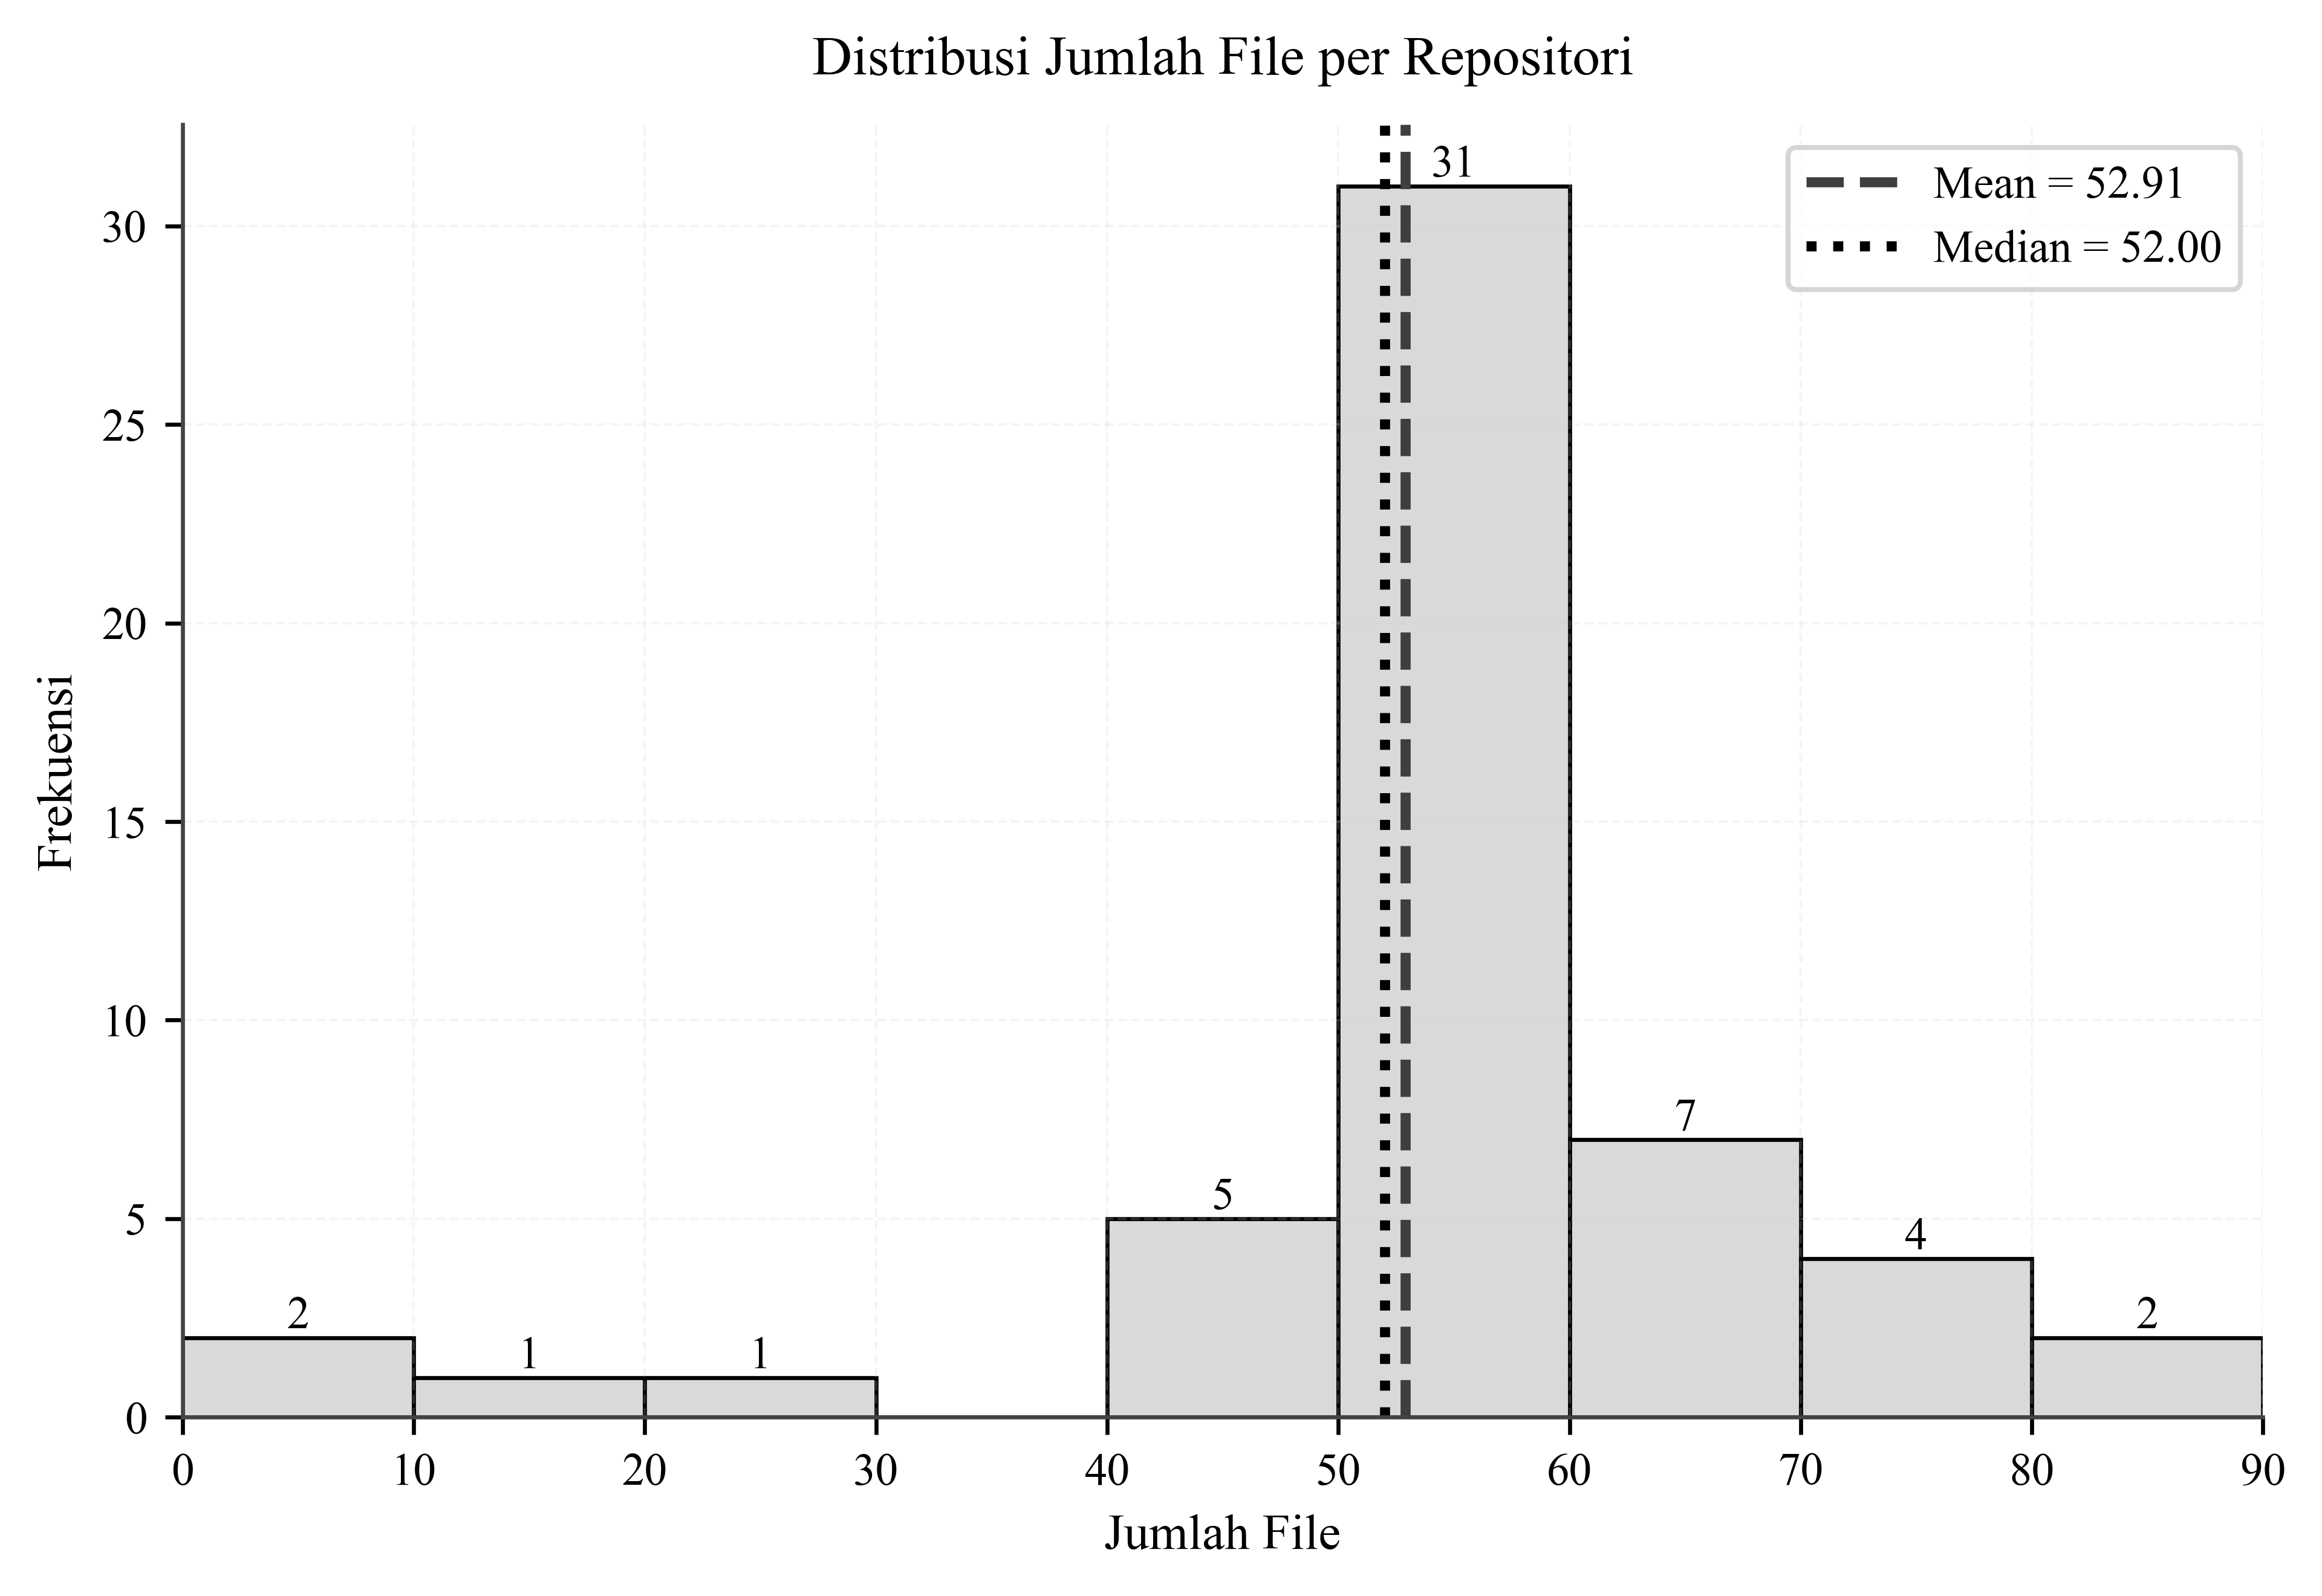

In [8]:
# =============================================================================
# GAMBAR 5.1 DISTRIBUSI JUMLAH FILE PER REPOSITORI
# =============================================================================

df_success = df[df["status"] == "SUCCESS"].copy()
data = df_success["total_files"]

# Bin per 10 file
bins = np.arange(0, data.max() + 10, 10)

fig, ax = plt.subplots()

# Histogram
counts, bin_edges, patches = ax.hist(
    data,
    bins=bins,
    color=COLOR_MAIN,
    edgecolor="black",
    linewidth=0.8
)
# Samakan tick sumbu X dengan interval histogram
ax.set_xticks(bins)
# Opsional: batasi sumbu agar pas
ax.set_xlim(bins[0], bins[-1])

# Label frekuensi pada setiap batang
for count, patch in zip(counts, patches):
    if count > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Mean
ax.axvline(
    data.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {data.mean():.2f}"
)

# Median
ax.axvline(
    data.median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {data.median():.2f}"
)

apply_style(
    "Distribusi Jumlah File per Repositori",
    "Jumlah File",
    "Frekuensi"
)

ax.legend()

# plt.savefig(
#     os.path.join(
#         OUTPUT_FOLDER,
#         "Gambar_5_1_Distribusi_Jumlah_File.png"
#     ),
#     dpi=DPI,
#     bbox_inches="tight"
# )

plt.show()

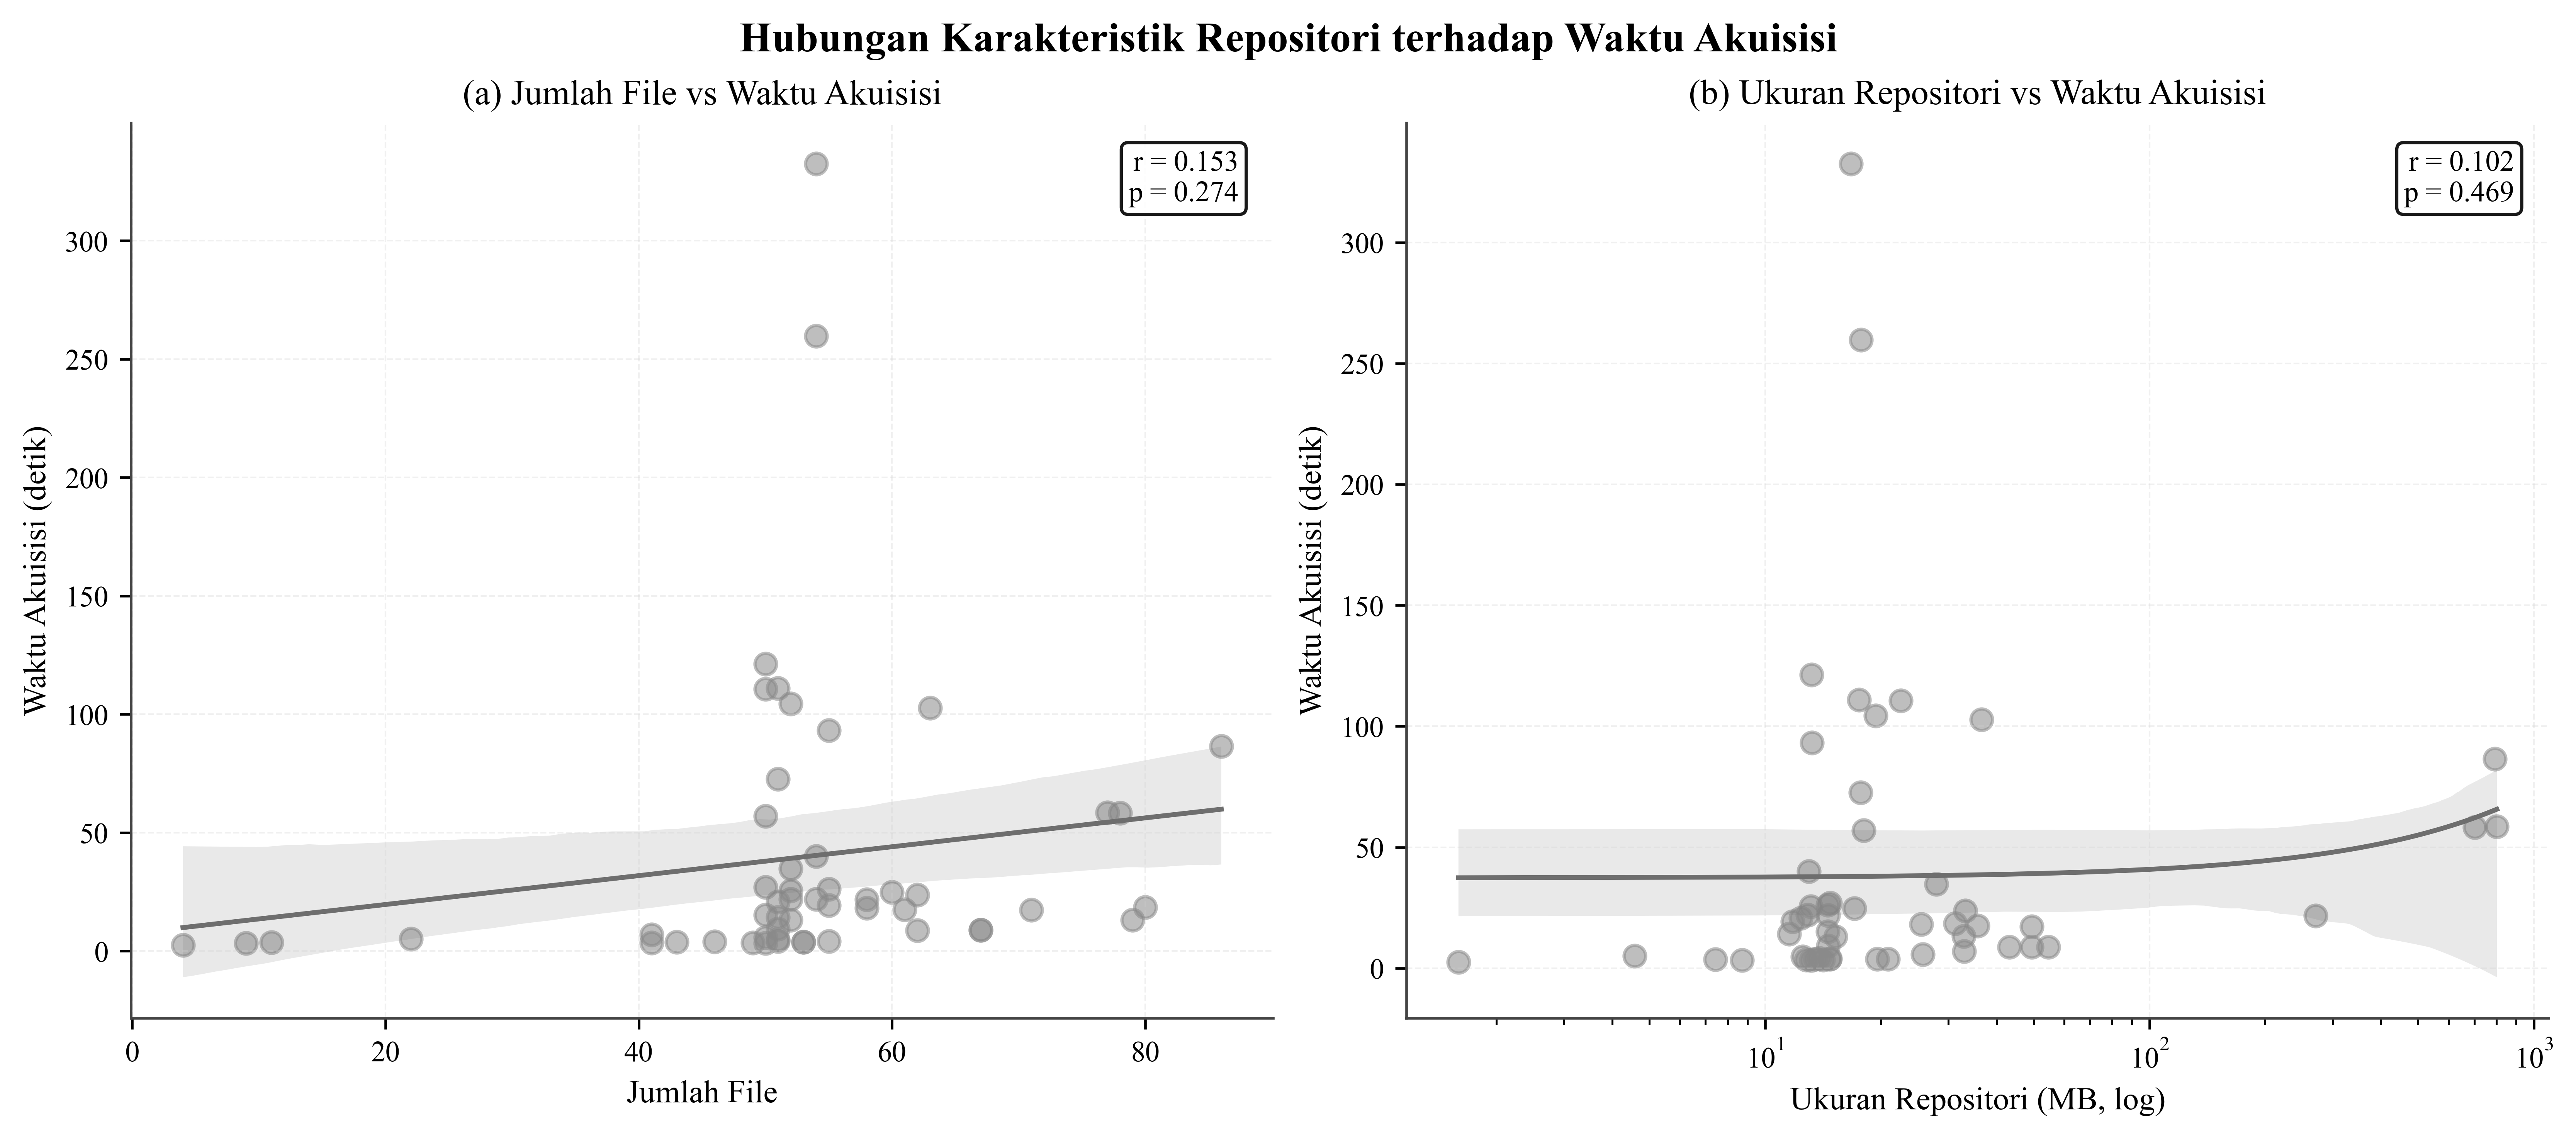

Saved: output(2)/visualisasi\Gambar_5_2_Faktor_Waktu_Akuisisi.png


In [92]:
# =============================================================================
# GAMBAR 5.2
# FAKTOR YANG BERHUBUNGAN DENGAN WAKTU AKUISISI
# =============================================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# DATA
df_success = df[df["status"] == "SUCCESS"].copy()
df_success["repo_size_mb"] = (
    df_success["repo_size_kb"] / 1024
)

# STYLE
POINT_COLOR = "#8A8A8A"
LINE_COLOR = "#6E6E6E"

# FIGURE
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    constrained_layout=True
)
# (a) JUMLAH FILE VS WAKTU AKUISISI
ax = axes[0]

x = df_success["total_files"]
y = df_success["execution_time_sec"]

r, p = pearsonr(x, y)

sns.regplot(
    x=x,
    y=y,
    ax=ax,
    scatter_kws={
        "s": 45,
        "alpha": 0.55,
        "color": POINT_COLOR
    },
    line_kws={
        "color": LINE_COLOR,
        "linewidth": 1.5
    }
)

ax.set_title("(a) Jumlah File vs Waktu Akuisisi")
ax.set_xlabel("Jumlah File")
ax.set_ylabel("Waktu Akuisisi (detik)")

ax.text(
    0.97,
    0.97,
    f"r = {r:.3f}\np = {p:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        alpha=0.9
    )
)
# (b) UKURAN REPOSITORI VS WAKTU AKUISISI
ax = axes[1]

x = df_success["repo_size_mb"]
y = df_success["execution_time_sec"]

r, p = pearsonr(x, y)

sns.regplot(
    x=x,
    y=y,
    ax=ax,
    scatter_kws={
        "s": 45,
        "alpha": 0.55,
        "color": POINT_COLOR
    },
    line_kws={
        "color": LINE_COLOR,
        "linewidth": 1.5
    }
)

ax.set_xscale("log")

ax.set_title("(b) Ukuran Repositori vs Waktu Akuisisi")
ax.set_xlabel("Ukuran Repositori (MB, log)")
ax.set_ylabel("Waktu Akuisisi (detik)")

ax.text(
    0.97,
    0.97,
    f"r = {r:.3f}\np = {p:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        alpha=0.9
    )
)
# GRID
for ax in axes:
    ax.grid(
        axis="both",
        linestyle="--",
        alpha=0.3
    )
# TITLE
fig.suptitle(
    "Hubungan Karakteristik Repositori terhadap Waktu Akuisisi",
    fontsize=13,
    fontweight="bold"
)
# SAVE
fig_path = os.path.join(
    OUTPUT_FOLDER,
    "Gambar_5_2_Faktor_Waktu_Akuisisi.png"
)

plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {fig_path}")

# 2. preprocessing

## conversion

In [96]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

FILE = "output(2)/03_conversion_report.xlsx"

df = pd.read_excel(FILE)

In [106]:
# =============================================================================
# SUMMARY
# =============================================================================

total_file = len(df)

summary_table = pd.DataFrame({
    "Metrik": [
        "Total File Diproses",
        "File Python (.py)",
        "File Notebook (.ipynb)",
        "Konversi Berhasil",
        "Syntax Error",
        "Konversi Gagal",
        "Overwrite",
        "Tingkat Keberhasilan (%)"
    ],
    "Nilai": [
        total_file,
        (df["file_type"] == "py").sum(),
        (df["file_type"] == "ipynb").sum(),
        (df["status"] == "SUCCESS").sum(),
        (df["status"] == "SYNTAX_ERR").sum(),
        (df["status"] == "FAILED").sum(),
        (df["status"] == "OVERWRITE").sum(),
        round(
            (df["status"] == "SUCCESS").sum()
            / total_file * 100,
            2
        )
    ]
})

with pd.ExcelWriter(
    FILE,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    summary_table.to_excel(
        writer,
        sheet_name="summary",
        index=False
    )

autofit_workbook(FILE)


print("Sheet 'summary' berhasil dibuat.")

Sheet 'summary' berhasil dibuat.


In [105]:
# =============================================================================
# TABEL 3 - FAILURE REASON
# =============================================================================

df_failed = df[df["status"] != "SUCCESS"].copy()

if len(df_failed) > 0:

    reason_summary = (
        df_failed["message"]
        .fillna("Unknown Error")
        .astype(str)
        .str.strip()
        .value_counts()
        .reset_index()
    )

    reason_summary.columns = [
        "Alasan Kegagalan",
        "Jumlah"
    ]

else:

    reason_summary = pd.DataFrame({
        "Alasan Kegagalan": ["Tidak ada kegagalan"],
        "Jumlah": [0]
    })

# =============================================================================
# SAVE
# =============================================================================

with pd.ExcelWriter(
    FILE,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    reason_summary.to_excel(
        writer,
        sheet_name="failed_reason",
        startrow=0,
        index=False
    )

# =============================================================================
# AUTO FIT
# =============================================================================
autofit_workbook(FILE, ["failed_reason"])
print("Failed reason sheet berhasil dibuat.")

Failed reason sheet berhasil dibuat.


## split dataset

In [109]:
from pathlib import Path
import pandas as pd
# PATH DATASET
PRAK_DIR = Path(
    r"D:\PUTRI\D4\SEMESTER 8 (4C)\SKRIPSI\code\dataset(2)\06_Filtered_prak"
)
TGS_DIR = Path(
    r"D:\PUTRI\D4\SEMESTER 8 (4C)\SKRIPSI\code\dataset(2)\06_Filtered_tgs"
)

OUTPUT_FILE = "D:\PUTRI\D4\SEMESTER 8 (4C)\SKRIPSI\code\output(2)\dataset_split_summary.xlsx"

# SCAN FILE
records = []

for kategori, root_dir in [
    ("Praktikum", PRAK_DIR),
    ("Tugas", TGS_DIR)
]:

    for file_path in root_dir.rglob("*.py"):
        rel_path = file_path.relative_to(root_dir)
        parts = rel_path.parts
        mahasiswa = parts[0] if len(parts) >= 1 else ""
        modul = parts[1] if len(parts) >= 2 else ""

        records.append({
            "Kategori": kategori,
            "Mahasiswa": mahasiswa,
            "Modul": modul,
            "Nama_File": file_path.name,
            "Path_Relatif": str(rel_path),
            "Ukuran_KB": round(file_path.stat().st_size / 1024, 2)
        })

# DETAIL
df_detail = pd.DataFrame(records)

# SUMMARY
summary_rows = []

for kategori in ["Praktikum", "Tugas"]:
    df_cat = df_detail[df_detail["Kategori"] == kategori]
    summary_rows.append({
        "Kategori": kategori,
        "Jumlah_Mahasiswa": df_cat["Mahasiswa"].nunique(),
        "Jumlah_Modul": df_cat["Modul"].nunique(),
        "Jumlah_File": len(df_cat),
        "Total_Ukuran_KB": round(df_cat["Ukuran_KB"].sum(), 2)
    })
df_summary = pd.DataFrame(summary_rows)

# EXPORT
with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    df_detail.to_excel(
        writer,
        sheet_name="Detail",
        index=False
    )

    df_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

autofit_workbook(OUTPUT_FILE)

display(df_summary)
print(f"\nTersimpan: {OUTPUT_FILE}")

,Kategori,Jumlah_Mahasiswa,Jumlah_Modul,Jumlah_File,Total_Ukuran_KB
0,Praktikum,53,11,1678,3939.00
1,Tugas,50,11,566,2171.67



Tersimpan: D:\PUTRI\D4\SEMESTER 8 (4C)\SKRIPSI\code\output(2)\dataset_split_summary.xlsx


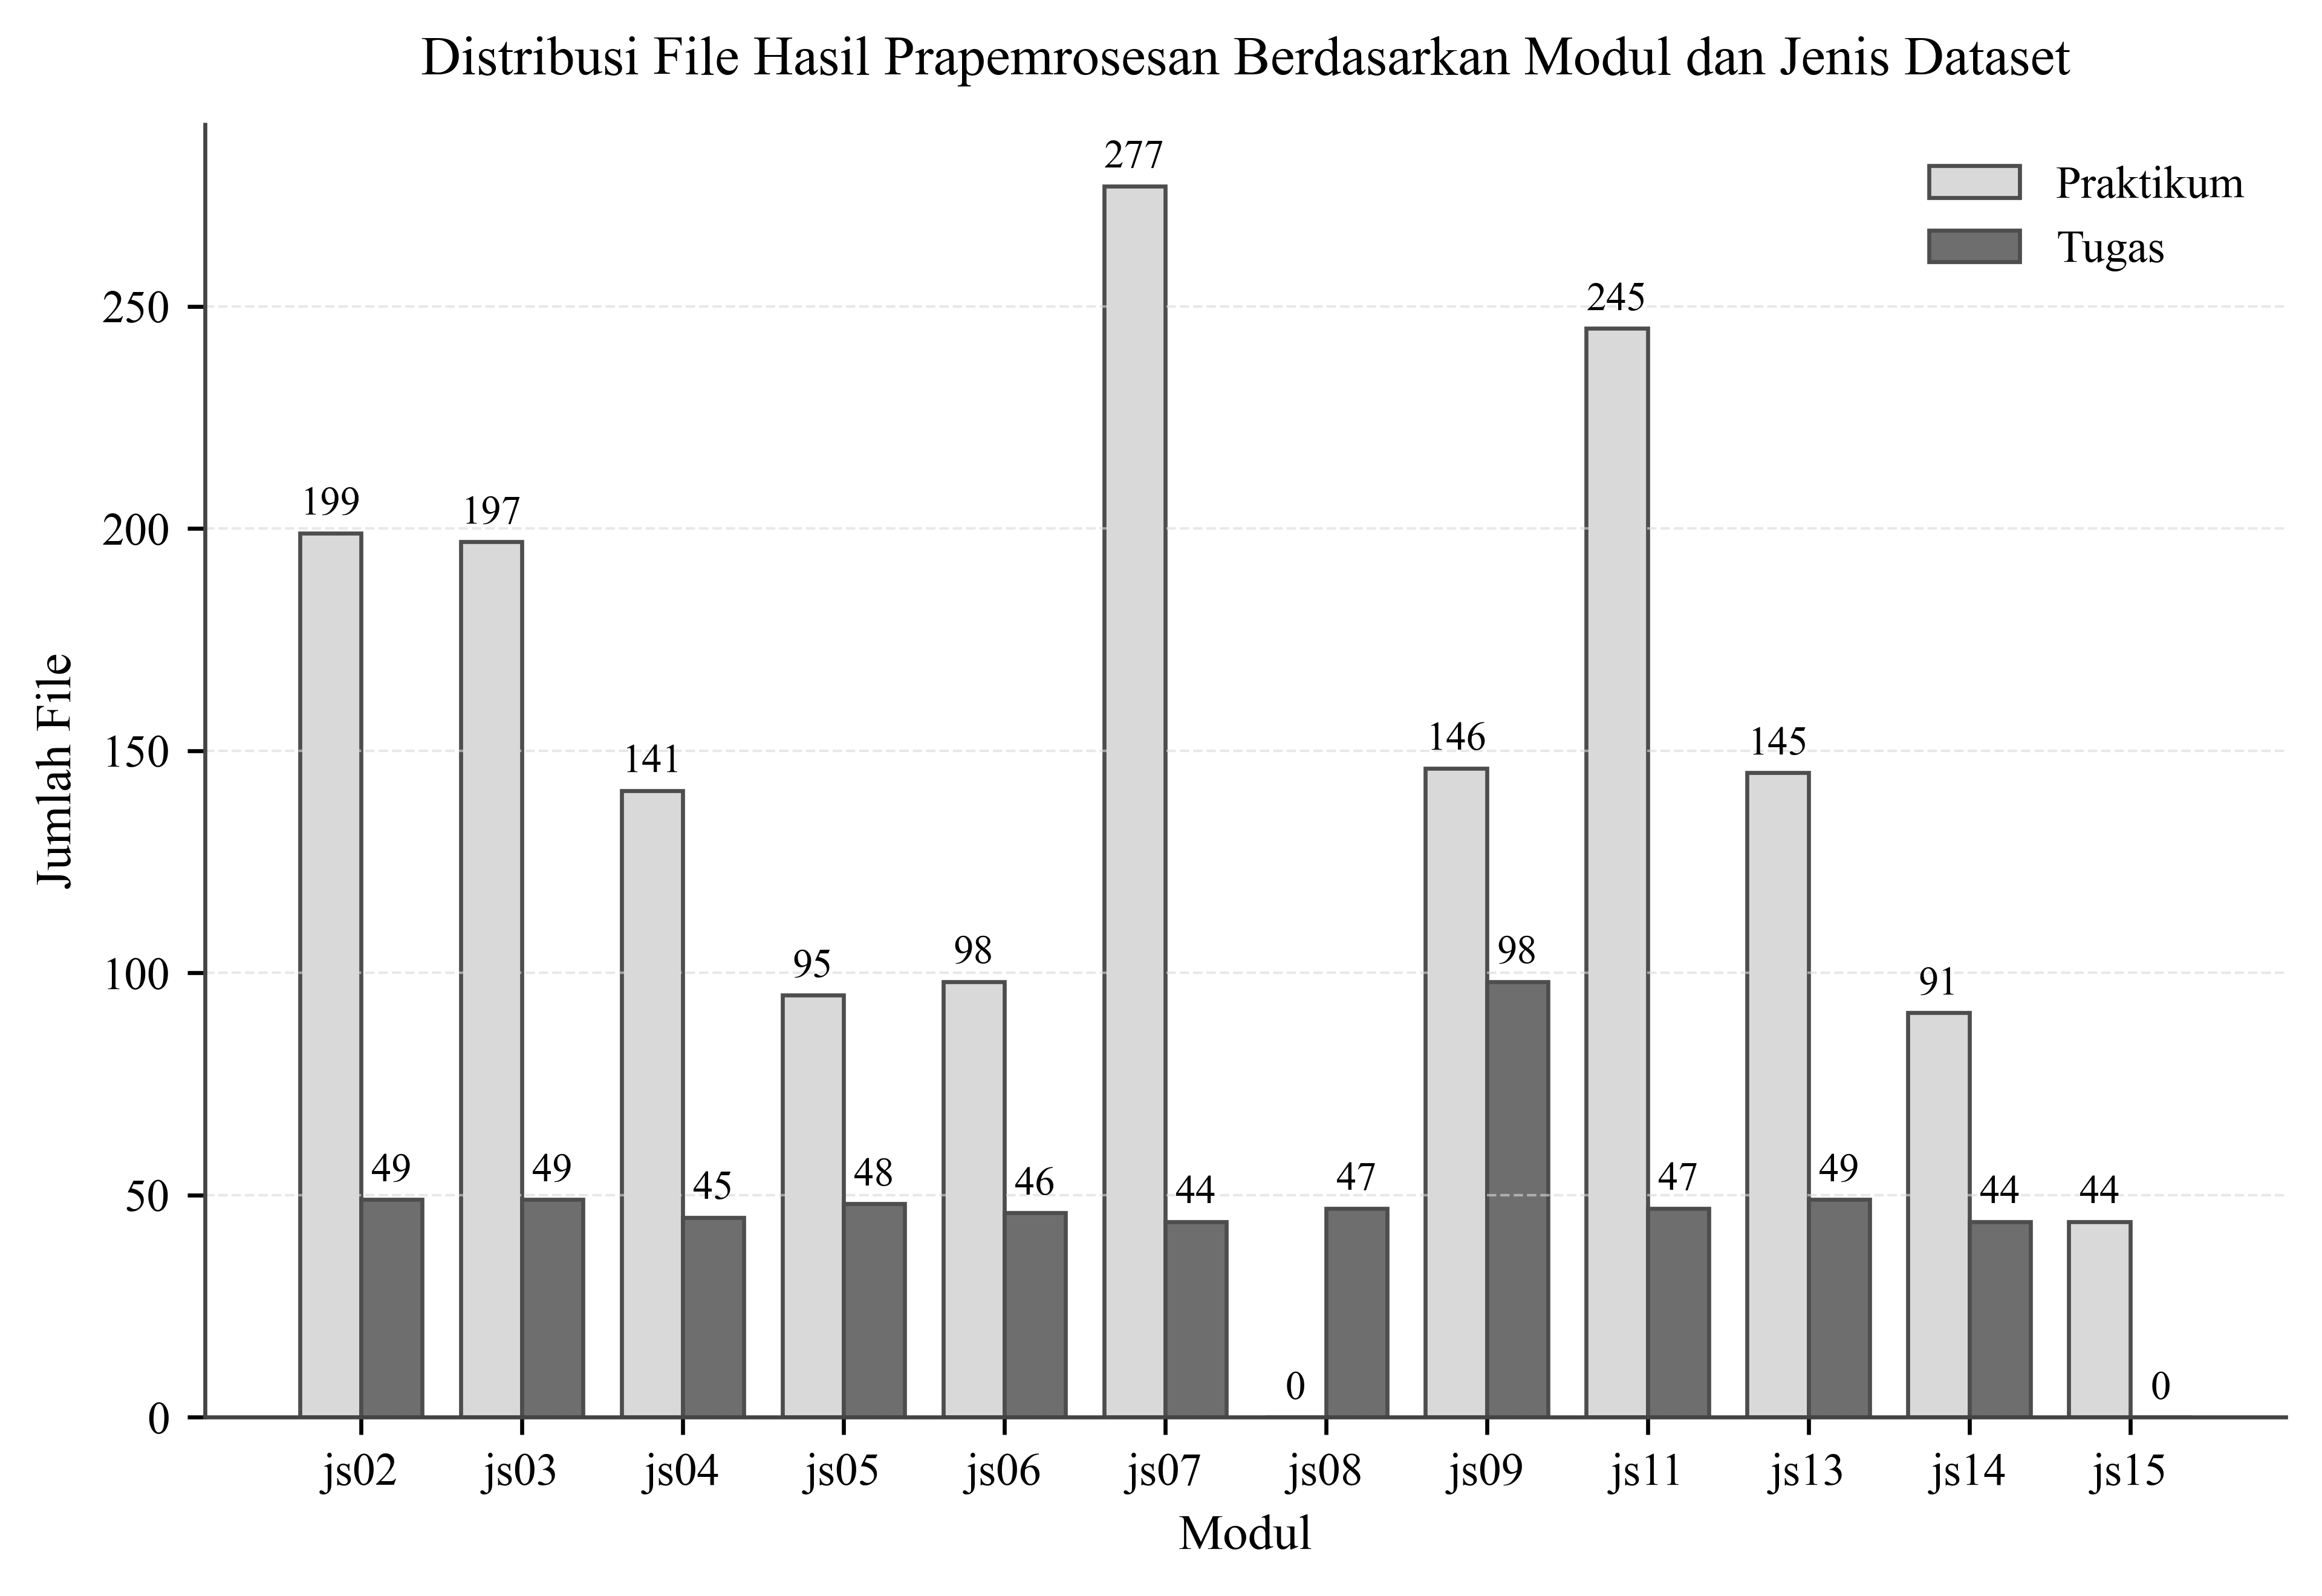

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE_EXCEL = "D:\PUTRI\D4\SEMESTER 8 (4C)\SKRIPSI\code\output(2)\dataset_split_summary.xlsx"

df = pd.read_excel(
    FILE_EXCEL,
    sheet_name="Detail"
)
PRAK_COLOR = "#D9D9D9"
TUGAS_COLOR = "#6E6E6E"

# ==============================================================================
# AGREGASI
# ==============================================================================

pivot = (
    df.groupby(["Modul", "Kategori"])
      .size()
      .unstack(fill_value=0)
)

# urutkan modul secara numerik jika nama modul mengandung angka
try:
    pivot = pivot.sort_index(
        key=lambda x: x.str.extract(r'(\d+)')[0].astype(int)
    )
except:
    pivot = pivot.sort_index()

# ==============================================================================
# PLOT
# ==============================================================================

fig, ax = plt.subplots()

x = np.arange(len(pivot.index))
width = 0.38

bars1 = ax.bar(
    x - width/2,
    pivot["Praktikum"],
    width,
    label="Praktikum",
    color=PRAK_COLOR,
    edgecolor="#4D4D4D",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    pivot["Tugas"],
    width,
    label="Tugas",
    color=TUGAS_COLOR,
    edgecolor="#4D4D4D",
    linewidth=0.8
)

# ==============================================================================
# LABEL NILAI
# ==============================================================================

for bars in [bars1, bars2]:
    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

# ==============================================================================
# FORMAT AXIS
# ==============================================================================

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)

apply_style(
    title="Distribusi File Hasil Prapemrosesan Berdasarkan Modul dan Jenis Dataset",
    xlabel="Modul",
    ylabel="Jumlah File"
)

ax.legend(
    frameon=False,
    loc="upper right"
)

# grid hanya horizontal
ax.xaxis.grid(False)
ax.yaxis.grid(
    True,
    linestyle="--",
    color=COLOR_GRID,
    alpha=0.6
)
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "Gambar_5_5_Distribusi_Modul_Praktikum_Tugas.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 3. AST

In [14]:
import pandas as pd

# =============================================================================
# LOAD DATA
# =============================================================================

AST_PRAK = "output(2)/07_AST_report_prak.xlsx"
AST_TGS  = "output(2)/07_AST_report_tgs.xlsx"

df_prak = pd.read_excel(AST_PRAK)
df_tgs = pd.read_excel(AST_TGS)

df_ast = pd.concat(
    [df_prak, df_tgs],
    ignore_index=True
)

# hanya AST berhasil
df_ast = df_ast[
    df_ast["status"] == "SUCCESS"
].copy()

display(df_ast.head())

,nim,modul,file,kedalaman_ast,jumlah_node,jumlah_function,jumlah_variabel_unik,cyclomatic_complexity,loc,status,keterangan
0,MHS010,js03,MHS010_js03_p02,6,46,0,3,1,12,SUCCESS,NaN
1,MHS044,js03,MHS044_js03_p02,6,46,0,3,1,12,SUCCESS,NaN
2,MHS048,js03,MHS048_js03_p02,6,46,0,3,1,12,SUCCESS,NaN
3,MHS045,js02,MHS045_js02_p02,9,50,0,1,1,6,SUCCESS,NaN
4,MHS037,js02,MHS037_js02_p02,9,52,0,1,1,8,SUCCESS,NaN


In [15]:
summary_process_prak = pd.DataFrame({
    "Metrik": [
        "Total File Sumber",
        "AST Berhasil Diekstraksi",
        "AST Gagal Diekstraksi",
        "Tingkat Keberhasilan (%)"
    ],
    "Nilai": [
        len(df_prak),
        (df_prak["status"] == "SUCCESS").sum(),
        (df_prak["status"] != "SUCCESS").sum(),
        round(
            ((df_prak["status"] == "SUCCESS").sum() /
             len(df_prak)) * 100,
            2
        )
    ]
})

prak_success = df_prak[df_prak["status"] == "SUCCESS"]

summary_ast_prak = pd.DataFrame({
    "Metrik": [
        "Kedalaman AST",
        "Jumlah Node AST",
        "Jumlah Function",
        "Jumlah Variabel Unik",
        "LOC"
    ],
    "Mean": [
        prak_success["kedalaman_ast"].mean(),
        prak_success["jumlah_node"].mean(),
        prak_success["jumlah_function"].mean(),
        prak_success["jumlah_variabel_unik"].mean(),
        prak_success["loc"].mean()
    ],
    "Median": [
        prak_success["kedalaman_ast"].median(),
        prak_success["jumlah_node"].median(),
        prak_success["jumlah_function"].median(),
        prak_success["jumlah_variabel_unik"].median(),
        prak_success["loc"].median()
    ],
    "Std": [
        prak_success["kedalaman_ast"].std(),
        prak_success["jumlah_node"].std(),
        prak_success["jumlah_function"].std(),
        prak_success["jumlah_variabel_unik"].std(),
        prak_success["loc"].std()
    ],
    "Min": [
        prak_success["kedalaman_ast"].min(),
        prak_success["jumlah_node"].min(),
        prak_success["jumlah_function"].min(),
        prak_success["jumlah_variabel_unik"].min(),
        prak_success["loc"].min()
    ],
    "Max": [
        prak_success["kedalaman_ast"].max(),
        prak_success["jumlah_node"].max(),
        prak_success["jumlah_function"].max(),
        prak_success["jumlah_variabel_unik"].max(),
        prak_success["loc"].max()
    ]
}).round(2)

print("PRAKTIKUM")
display(summary_ast_prak.head())

with pd.ExcelWriter(
    AST_PRAK,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    summary_process_prak.to_excel(
        writer,
        sheet_name="summary_process",
        index=False
    )

    summary_ast_prak.to_excel(
        writer,
        sheet_name="summary_ast",
        index=False
    )

autofit_workbook(AST_PRAK)
print("Summary Praktikum tersimpan.")

PRAKTIKUM


,Metrik,Mean,Median,Std,Min,Max
0,Kedalaman AST,8.63,9.0,1.71,5,14
1,Jumlah Node AST,600.43,487.0,486.25,46,6439
2,Jumlah Function,1.17,0.0,2.39,0,18
3,Jumlah Variabel Unik,18.51,15.0,13.42,0,135
4,LOC,67.78,55.0,53.91,4,774


Summary Praktikum tersimpan.


In [16]:
summary_process_tgs = pd.DataFrame({
    "Metrik": [
        "Total File Sumber",
        "AST Berhasil Diekstraksi",
        "AST Gagal Diekstraksi",
        "Tingkat Keberhasilan (%)"
    ],
    "Nilai": [
        len(df_tgs),
        (df_tgs["status"] == "SUCCESS").sum(),
        (df_tgs["status"] != "SUCCESS").sum(),
        round(
            ((df_tgs["status"] == "SUCCESS").sum() /
             len(df_tgs)) * 100,
            2
        )
    ]
})

tgs_success = df_tgs[df_tgs["status"] == "SUCCESS"]

summary_ast_tgs = pd.DataFrame({
    "Metrik": [
        "Kedalaman AST",
        "Jumlah Node AST",
        "Jumlah Function",
        "Jumlah Variabel Unik",
        "LOC"
    ],
    "Mean": [
        tgs_success["kedalaman_ast"].mean(),
        tgs_success["jumlah_node"].mean(),
        tgs_success["jumlah_function"].mean(),
        tgs_success["jumlah_variabel_unik"].mean(),
        tgs_success["loc"].mean()
    ],
    "Median": [
        tgs_success["kedalaman_ast"].median(),
        tgs_success["jumlah_node"].median(),
        tgs_success["jumlah_function"].median(),
        tgs_success["jumlah_variabel_unik"].median(),
        tgs_success["loc"].median()
    ],
    "Std": [
        tgs_success["kedalaman_ast"].std(),
        tgs_success["jumlah_node"].std(),
        tgs_success["jumlah_function"].std(),
        tgs_success["jumlah_variabel_unik"].std(),
        tgs_success["loc"].std()
    ],
    "Min": [
        tgs_success["kedalaman_ast"].min(),
        tgs_success["jumlah_node"].min(),
        tgs_success["jumlah_function"].min(),
        tgs_success["jumlah_variabel_unik"].min(),
        tgs_success["loc"].min()
    ],
    "Max": [
        tgs_success["kedalaman_ast"].max(),
        tgs_success["jumlah_node"].max(),
        tgs_success["jumlah_function"].max(),
        tgs_success["jumlah_variabel_unik"].max(),
        tgs_success["loc"].max()
    ]
}).round(2)

print("TUGAS")
display(summary_ast_tgs.head())

with pd.ExcelWriter(
    AST_TGS,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    summary_process_tgs.to_excel(
        writer,
        sheet_name="summary_process",
        index=False
    )

    summary_ast_tgs.to_excel(
        writer,
        sheet_name="summary_ast",
        index=False
    )

autofit_workbook(AST_TGS)
print("Summary Tugas tersimpan.")

TUGAS


,Metrik,Mean,Median,Std,Min,Max
0,Kedalaman AST,8.69,8.0,1.75,5,17
1,Jumlah Node AST,841.17,630.5,700.80,89,5600
2,Jumlah Function,0.64,0.0,2.16,0,32
3,Jumlah Variabel Unik,26.21,23.0,18.23,3,125
4,LOC,103.45,79.0,87.74,9,701


Summary Tugas tersimpan.


In [17]:
prak_success = df_prak[df_prak["status"] == "SUCCESS"]
tgs_success  = df_tgs[df_tgs["status"] == "SUCCESS"]

table_57 = pd.DataFrame({

    "Variabel": [
        "Jumlah Node AST",
        "Jumlah Node AST",
        "Kedalaman AST",
        "Kedalaman AST"
    ],

    "Dataset": [
        "Praktikum",
        "Tugas",
        "Praktikum",
        "Tugas"
    ],

    "Mean": [
        prak_success["jumlah_node"].mean(),
        tgs_success["jumlah_node"].mean(),

        prak_success["kedalaman_ast"].mean(),
        tgs_success["kedalaman_ast"].mean()
    ],

    "Median": [
        prak_success["jumlah_node"].median(),
        tgs_success["jumlah_node"].median(),

        prak_success["kedalaman_ast"].median(),
        tgs_success["kedalaman_ast"].median()
    ],

    "Std": [
        prak_success["jumlah_node"].std(),
        tgs_success["jumlah_node"].std(),

        prak_success["kedalaman_ast"].std(),
        tgs_success["kedalaman_ast"].std()
    ],

    "Min": [
        prak_success["jumlah_node"].min(),
        tgs_success["jumlah_node"].min(),

        prak_success["kedalaman_ast"].min(),
        tgs_success["kedalaman_ast"].min()
    ],

    "Max": [
        prak_success["jumlah_node"].max(),
        tgs_success["jumlah_node"].max(),

        prak_success["kedalaman_ast"].max(),
        tgs_success["kedalaman_ast"].max()
    ]
}).round(2)

with pd.ExcelWriter(
    AST_TGS,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    table_57.to_excel(
        writer,
        sheet_name="statistik_deskriptif",
        index=False
    )
    
with pd.ExcelWriter(
    AST_PRAK,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    table_57.to_excel(
        writer,
        sheet_name="statistik_deskriptif",
        index=False
    )


display(table_57)

,Variabel,Dataset,Mean,Median,Std,Min,Max
0,Jumlah Node AST,Praktikum,600.43,487.0,486.25,46,6439
1,Jumlah Node AST,Tugas,841.17,630.5,700.80,89,5600
2,Kedalaman AST,Praktikum,8.63,9.0,1.71,5,14
3,Kedalaman AST,Tugas,8.69,8.0,1.75,5,17


## visualisasi AST

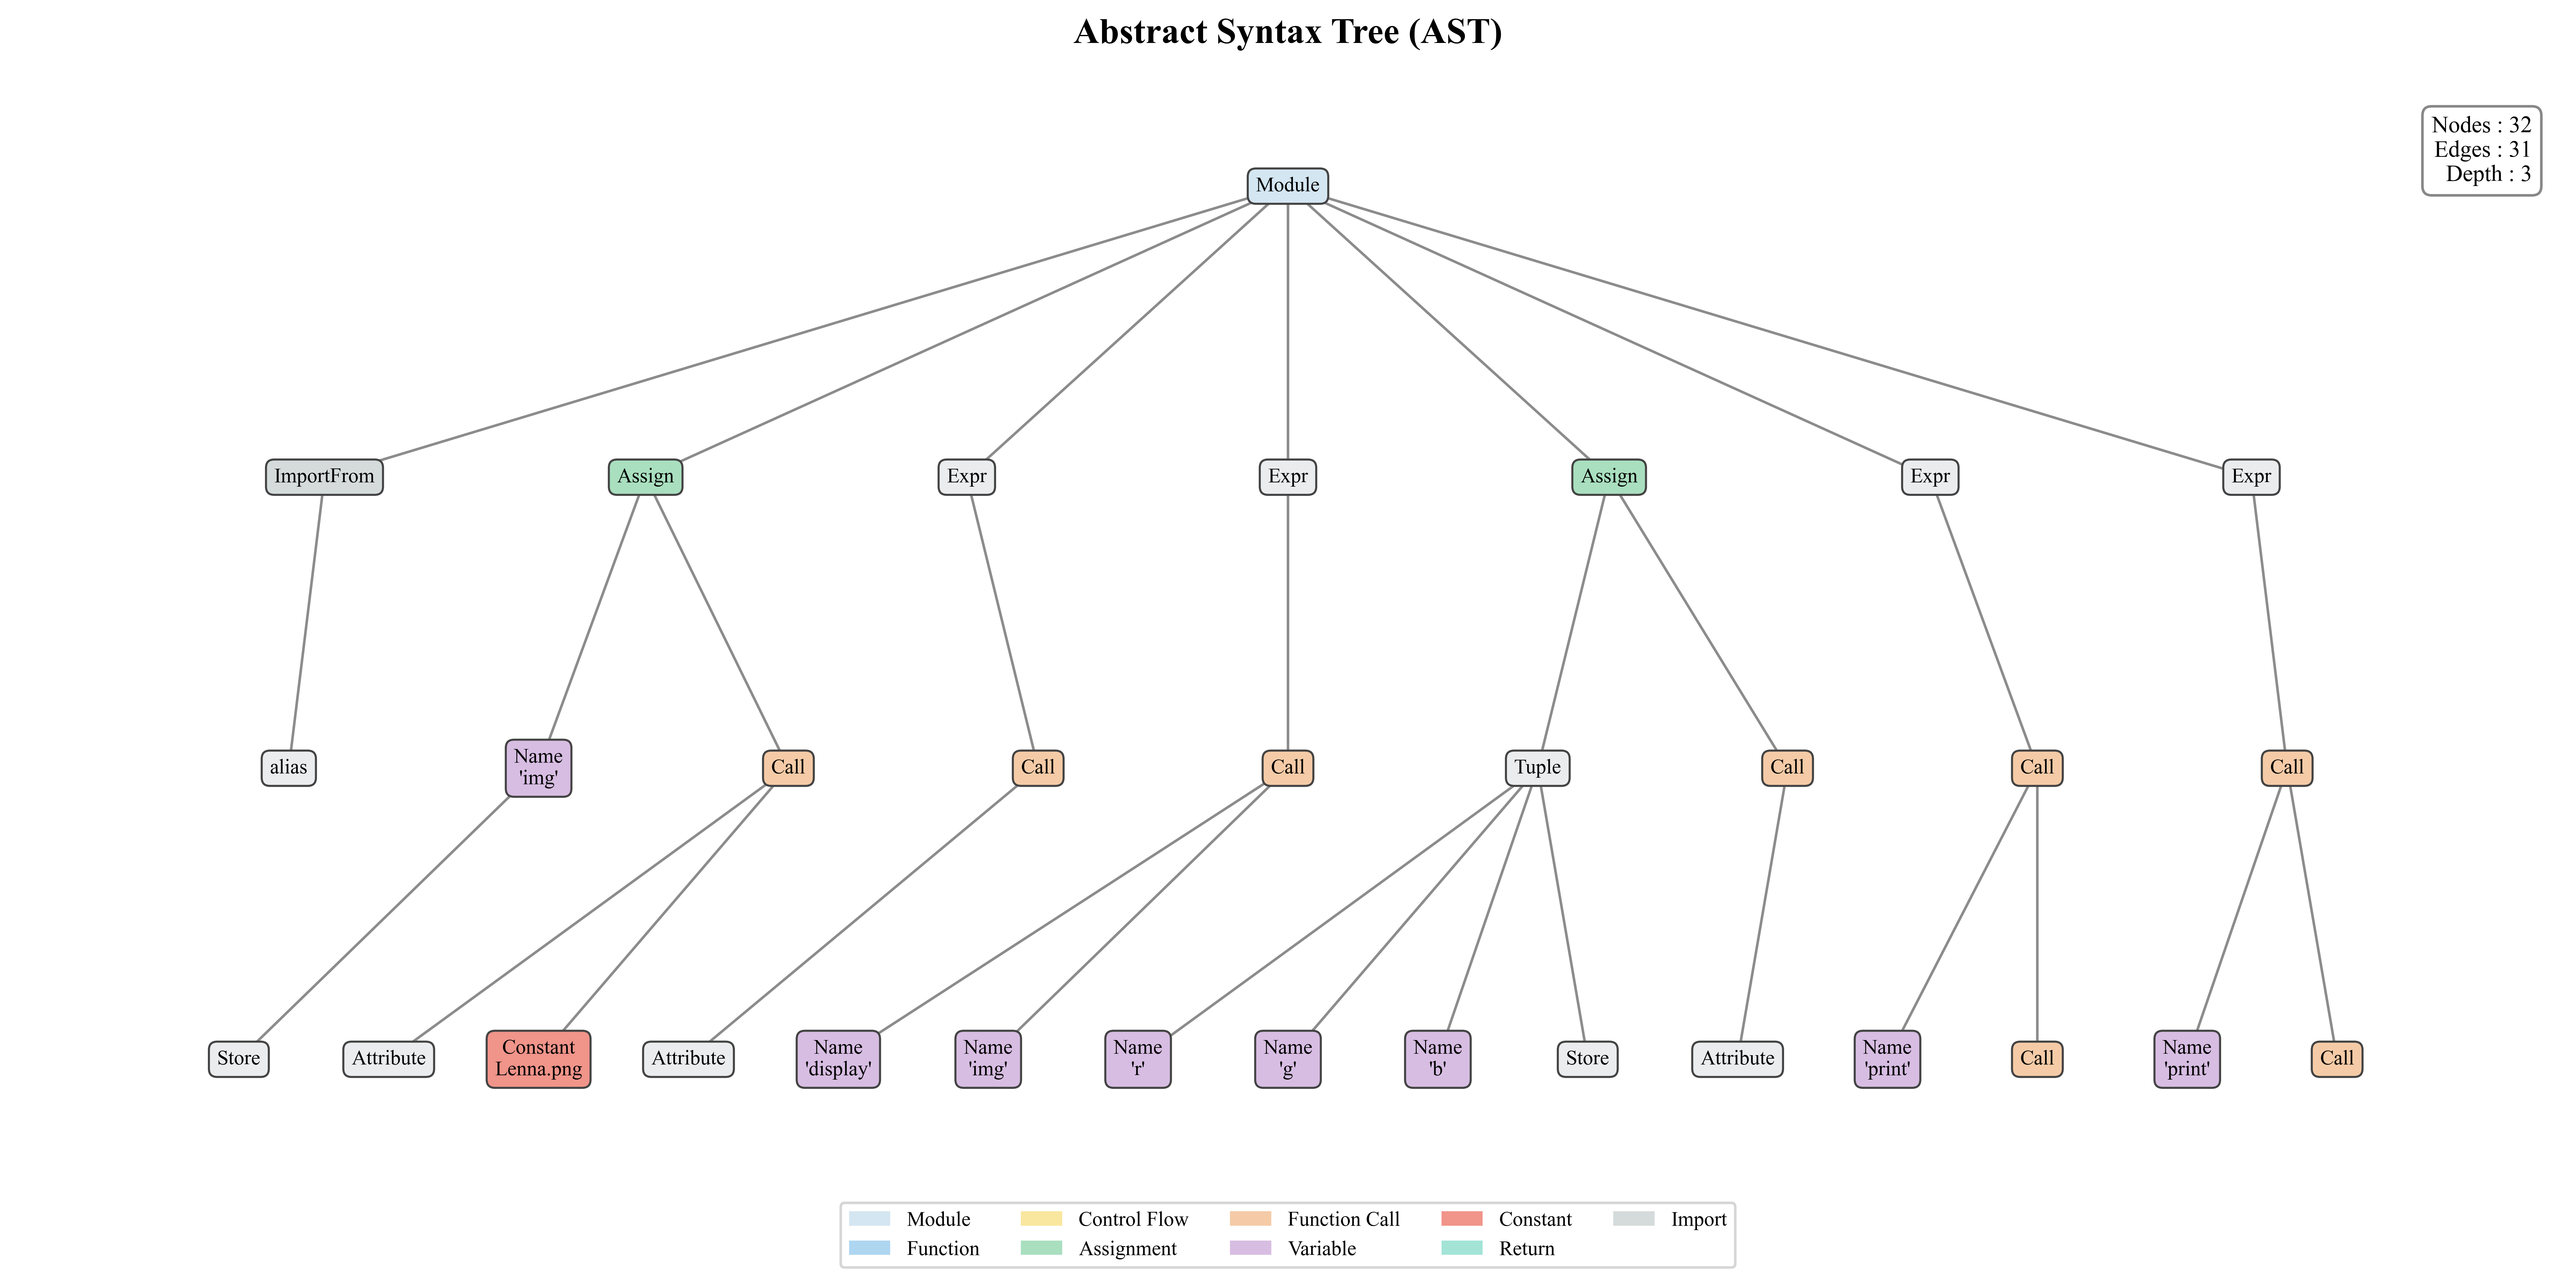

AST image saved: output(2)/visualisasi/Gambar_5_7_AST.png
Total nodes visualized : 32
Total edges visualized : 31


In [18]:
# =============================================================================
# AST TREE VISUALIZATION (THESIS VERSION)
# =============================================================================

import ast
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# =============================================================================
# CONFIGURATION
# =============================================================================

SOURCE_FILE = "dataset(2)/06_Filtered_prak/MHS044/js03/MHS044_js03_p04.py"
OUTPUT_IMAGE = "output(2)/visualisasi/Gambar_5_7_AST.png"

MAX_DEPTH = 3

DPI = 600

# =============================================================================
# COLOR MAP
# =============================================================================

NODE_COLORS = {

    # Root
    "Module": "#D4E6F1",

    # Function
    "FunctionDef": "#AED6F1",
    "AsyncFunctionDef": "#AED6F1",
    "arguments": "#AED6F1",
    "arg": "#AED6F1",

    # Class
    "ClassDef": "#85C1E9",

    # Control Flow
    "If": "#F9E79F",
    "For": "#F7DC6F",
    "While": "#F7DC6F",
    "Try": "#FAD7A0",

    # Assignment
    "Assign": "#A9DFBF",
    "AugAssign": "#A9DFBF",

    # Function Call
    "Call": "#F5CBA7",

    # Variable
    "Name": "#D7BDE2",

    # Constant
    "Constant": "#F1948A",

    # Return
    "Return": "#A3E4D7",

    # Import
    "Import": "#D5DBDB",
    "ImportFrom": "#D5DBDB"
}

DEFAULT_COLOR = "#EAECEE"

# =============================================================================
# LOAD SOURCE CODE
# =============================================================================

with open(SOURCE_FILE, "r", encoding="utf-8") as f:
    source_code = f.read()

tree = ast.parse(source_code)

# =============================================================================
# BUILD AST GRAPH
# =============================================================================

def build_ast_graph(
    node,
    graph=None,
    parent_id=None,
    node_id=0,
    depth=0,
    max_depth=4
):

    if graph is None:
        graph = nx.DiGraph()

    if depth > max_depth:
        return graph, node_id

    node_type = type(node).__name__

    label = node_type

    # -------------------------------------------------------------------------
    # ENRICH LABEL
    # -------------------------------------------------------------------------

    if isinstance(node, ast.Name):
        label += f"\n'{node.id}'"

    elif isinstance(node, ast.Constant):
        value = str(node.value)
        if len(value) > 15:
            value = value[:15] + "..."
        label += f"\n{value}"

    elif isinstance(node, ast.arg):
        label += f"\n'{node.arg}'"

    elif isinstance(node, ast.FunctionDef):
        label += f"\n'{node.name}'"

    elif isinstance(node, ast.ClassDef):
        label += f"\n'{node.name}'"

    current_id = node_id

    graph.add_node(
        current_id,
        label=label,
        node_type=node_type,
        color=NODE_COLORS.get(
            node_type,
            DEFAULT_COLOR
        )
    )

    if parent_id is not None:
        graph.add_edge(
            parent_id,
            current_id
        )

    next_id = current_id + 1

    for child in ast.iter_child_nodes(node):

        graph, next_id = build_ast_graph(
            child,
            graph,
            current_id,
            next_id,
            depth + 1,
            max_depth
        )

    return graph, next_id

# =============================================================================
# IMPROVED HIERARCHICAL LAYOUT
# =============================================================================
def hierarchy_pos(
    G,
    root=0,
    width=1.0,
    vert_gap=0.18,
    vert_loc=0,
    xcenter=0.5
):
    levels = defaultdict(list)

    def traverse(node, level=0):
        levels[level].append(node)
        for child in G.successors(node):
            traverse(child, level + 1)

    traverse(root)
    pos = {}
    spread_factor = 0.75
    for level, nodes in levels.items():

        n = len(nodes)
        xs = [
            0.5 + ((i - (n - 1)/2) / max(n,1))
            * spread_factor
            for i in range(n)
        ]

        for node, x in zip(nodes, xs):
            pos[node] = (
                x,
                -level * vert_gap
            )
    return pos

# =============================================================================
# BUILD GRAPH
# =============================================================================

G, _ = build_ast_graph(
    tree,
    max_depth=MAX_DEPTH
)

pos = hierarchy_pos(G)

labels = nx.get_node_attributes(
    G,
    "label"
)

TOTAL_NODES = len(G.nodes())
TOTAL_EDGES = len(G.edges())
# =============================================================================
# FIGURE SIZE AUTO
# =============================================================================

max_level_nodes = 1

levels = defaultdict(int)

for _, y in pos.values():
    levels[y] += 1

max_level_nodes = max(levels.values())

fig_width = max(
    14,
    max_level_nodes * 0.55
)

fig_height = max(
    7,
    MAX_DEPTH * 2.2
)

plt.figure(
    figsize=(fig_width, fig_height),
    dpi=DPI
)

# =============================================================================
# DRAW EDGES
# =============================================================================

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="#707070",
    width=1.0,
    arrows=False,
    alpha=0.8
)

# =============================================================================
# DRAW NODES AS ROUNDED BOXES
# =============================================================================

for node_id, (x, y) in pos.items():

    node_color = G.nodes[node_id]["color"]

    plt.text(
        x,
        y,

        labels[node_id],

        fontsize=8,
        ha="center",
        va="center",

        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor=node_color,
            edgecolor="#444444",
            linewidth=0.8
        )
    )

# =============================================================================
# AST INFORMATION BOX
# =============================================================================

plt.gca().text(
    0.99,
    0.98,

    f"Nodes : {TOTAL_NODES}\n"
    f"Edges : {TOTAL_EDGES}\n"
    f"Depth : {MAX_DEPTH}",

    transform=plt.gca().transAxes,

    ha="right",
    va="top",

    fontsize=9,

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="#888888"
    )
)
# =============================================================================
# FINAL LAYOUT
# =============================================================================

plt.axis("off")

plt.title(
    f"Abstract Syntax Tree (AST)",
    fontsize=14,
    fontweight="bold",
    pad=20
)


# =============================================================================
# LEGEND
# =============================================================================

legend_elements = [
    Patch(facecolor="#D4E6F1", label="Module"),
    Patch(facecolor="#AED6F1", label="Function"),
    Patch(facecolor="#F9E79F", label="Control Flow"),
    Patch(facecolor="#A9DFBF", label="Assignment"),
    Patch(facecolor="#F5CBA7", label="Function Call"),
    Patch(facecolor="#D7BDE2", label="Variable"),
    Patch(facecolor="#F1948A", label="Constant"),
    Patch(facecolor="#A3E4D7", label="Return"),
    Patch(facecolor="#D5DBDB", label="Import")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True,
    fontsize=8
)

plt.tight_layout()

# SAVE
plt.savefig(
    OUTPUT_IMAGE,
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

print(f"AST image saved: {OUTPUT_IMAGE}")
print(f"Total nodes visualized : {len(G.nodes())}")
print(f"Total edges visualized : {len(G.edges())}")

## graph

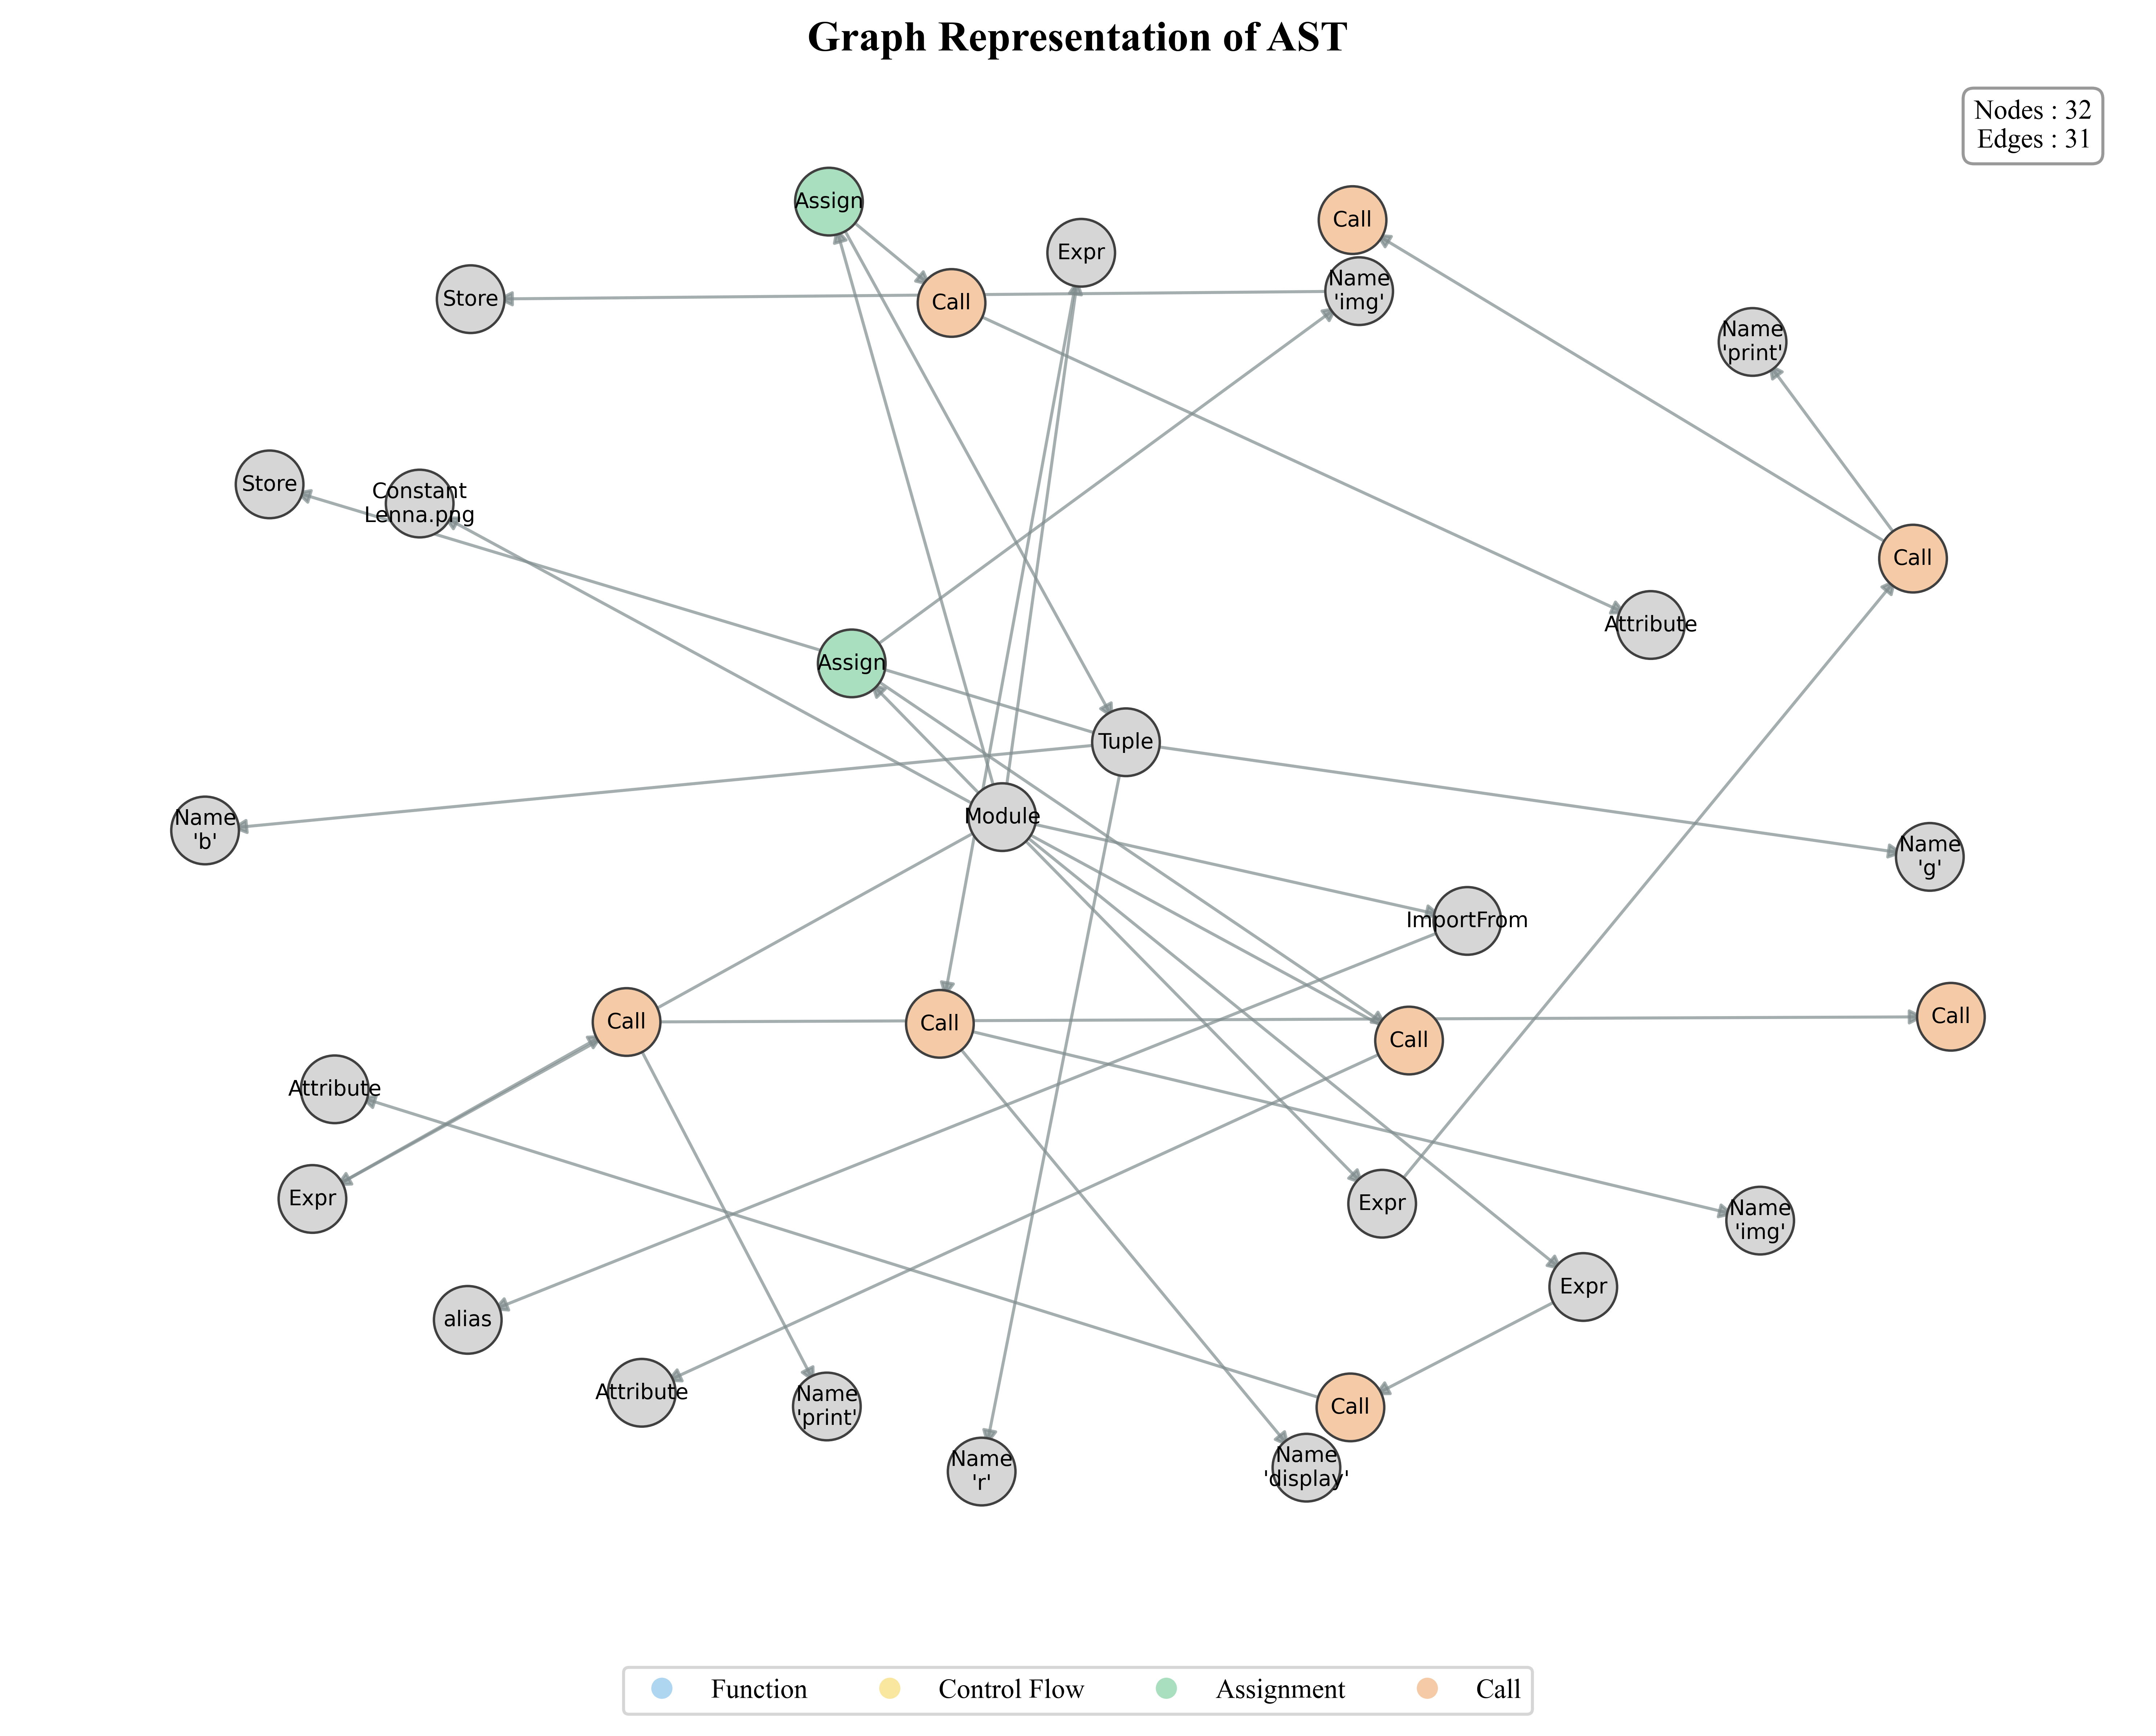

Saved : output(2)/visualisasi/Gambar_5_8_Graph.png
Nodes : 32
Edges : 31


In [19]:
# =============================================================================
# GRAPH VISUALIZATION
# =============================================================================

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUTPUT_IMAGE = ("output(2)/visualisasi/Gambar_5_8_Graph.png")

# =============================================================================
# FIGURE
# =============================================================================

plt.figure(
    figsize=(10, 8),
    dpi=600
)

# =============================================================================
# LAYOUT
# =============================================================================

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2
)

# =============================================================================
# NODE COLOR
# =============================================================================

node_types = nx.get_node_attributes(
    G,
    "label"
)

node_colors = []

for node in G.nodes():

    label = str(
        node_types.get(node, "")
    )

    if "FunctionDef" in label:
        node_colors.append("#AED6F1")

    elif "If" in label:
        node_colors.append("#F9E79F")

    elif "For" in label:
        node_colors.append("#F7DC6F")

    elif "Assign" in label:
        node_colors.append("#A9DFBF")

    elif "Call" in label:
        node_colors.append("#F5CBA7")

    else:
        node_colors.append("#D6D6D6")

# =============================================================================
# DRAW GRAPH
# =============================================================================

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="#7F8C8D",
    alpha=0.7,
    width=1
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors="#404040",
    linewidths=0.8,
    node_size=500
)

# =============================================================================
# LABELS
# =============================================================================

labels = nx.get_node_attributes(
    G,
    "label"
)

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=7
)

# =============================================================================
# INFORMATION BOX
# =============================================================================

plt.gca().text(
    0.98,
    0.98,

    f"Nodes : {G.number_of_nodes()}\n"
    f"Edges : {G.number_of_edges()}",

    transform=plt.gca().transAxes,

    ha="right",
    va="top",

    fontsize=9,

    bbox=dict(
        facecolor="white",
        edgecolor="#999999",
        boxstyle="round,pad=0.4"
    )
)

# =============================================================================
# LEGEND
# =============================================================================

legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Function',
        markerfacecolor='#AED6F1',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Control Flow',
        markerfacecolor='#F9E79F',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Assignment',
        markerfacecolor='#A9DFBF',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Call',
        markerfacecolor='#F5CBA7',
        markersize=8
    )
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=4
)

# =============================================================================
# FINALIZE
# =============================================================================

plt.title(
    "Graph Representation of AST",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_IMAGE,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Saved : {OUTPUT_IMAGE}")
print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")

In [20]:
# =============================================================================
# GAMBAR 5.10 DISTRIBUSI JUMLAH NODE GRAPH
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# LOAD DATA
# =============================================================================

df_prak = pd.read_excel(
    "output(2)/08_Graph_report_prak.xlsx"
)

df_tgs = pd.read_excel(
    "output(2)/08_Graph_report_tgs.xlsx"
)

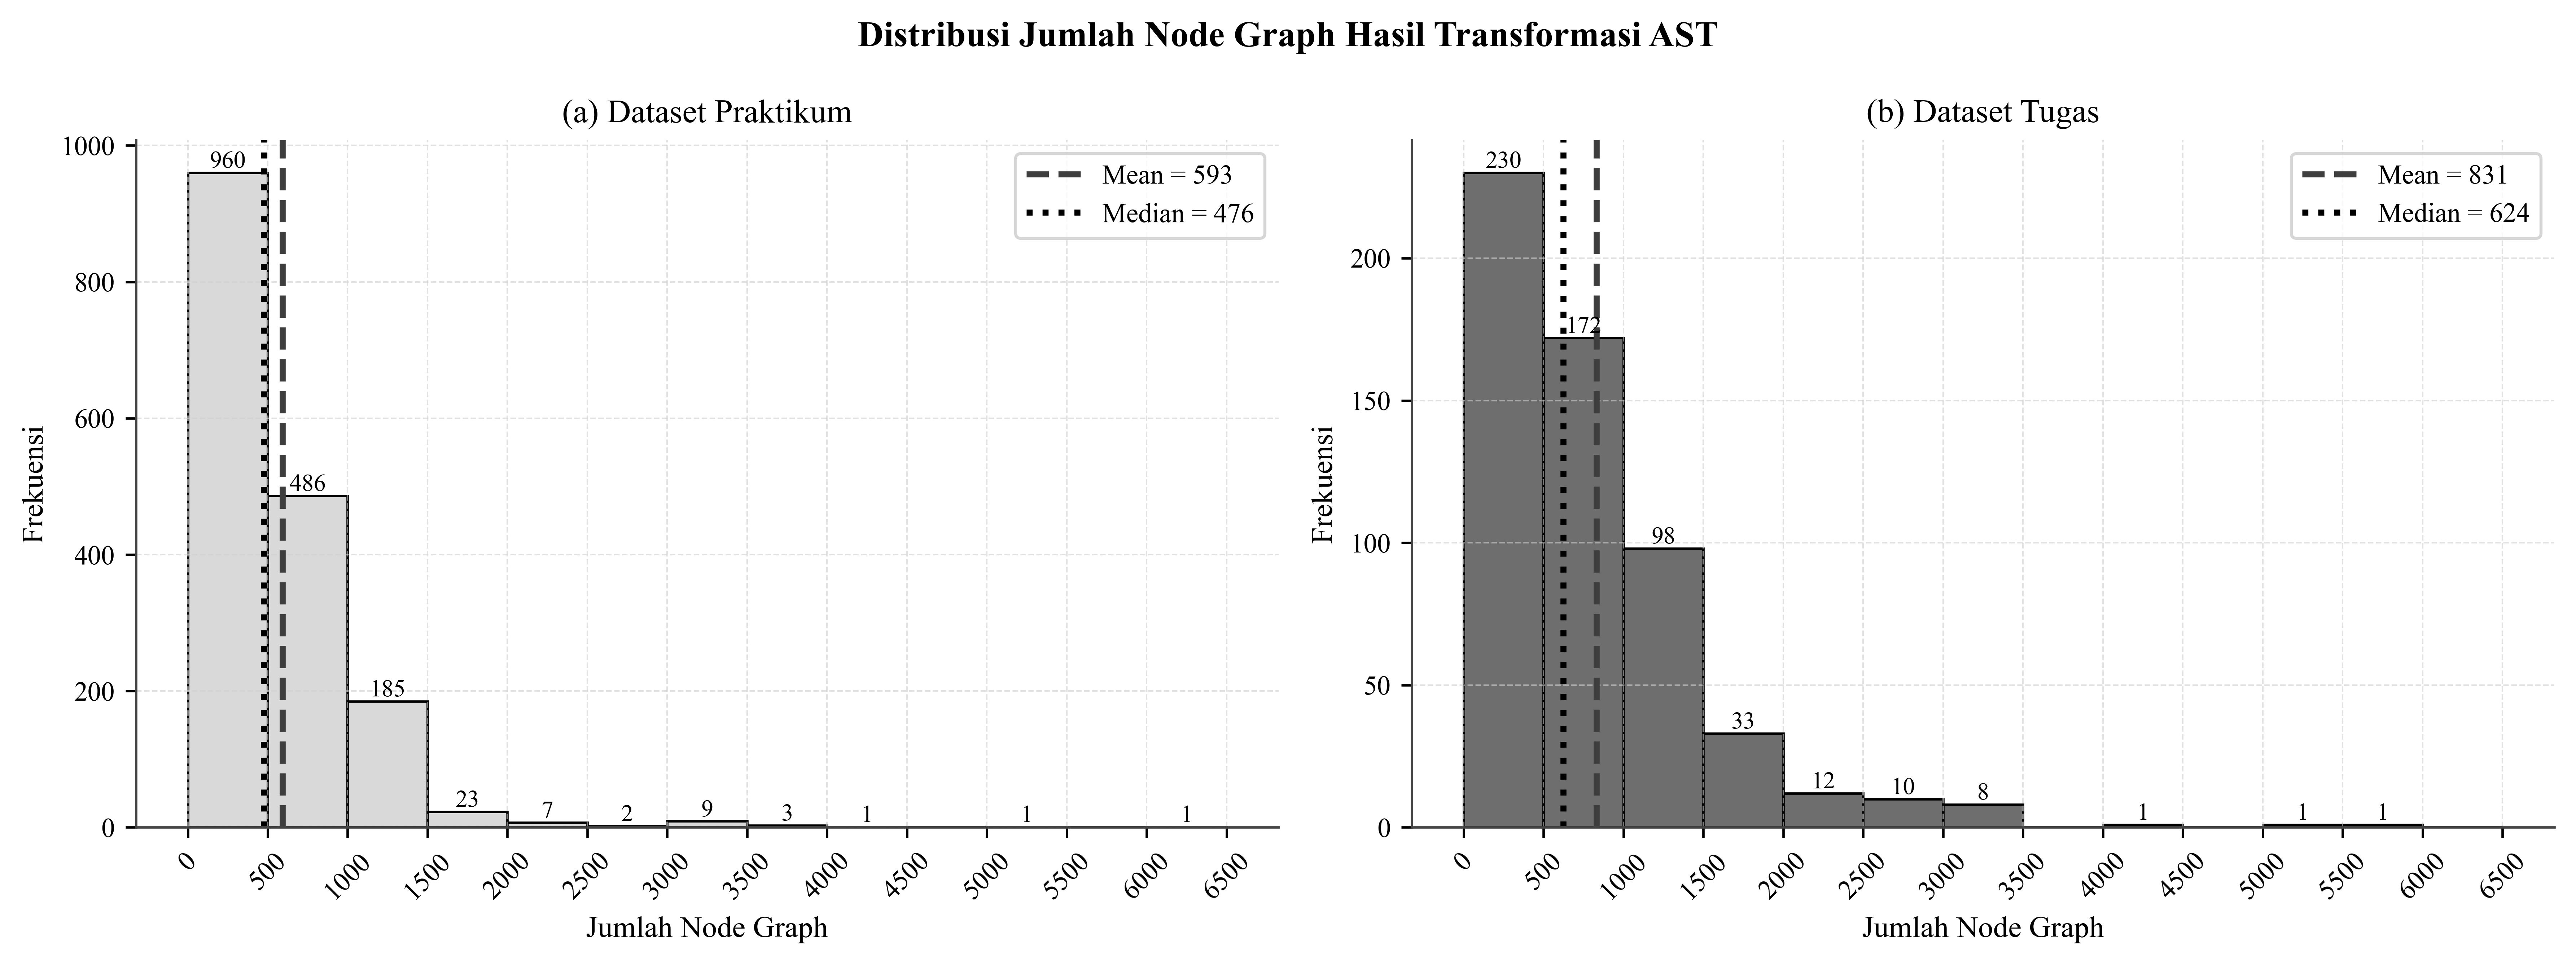

Gambar disimpan: output(2)/visualisasi\Gambar_5_10_Distribusi_Node_Graph.png


In [21]:
# =============================================================================
# GAMBAR 5.10 DISTRIBUSI JUMLAH NODE GRAPH
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FILTER SUCCESS
# =============================================================================

df_prak_success = df_prak[
    df_prak["status"] == "SUCCESS"
].copy()

df_tgs_success = df_tgs[
    df_tgs["status"] == "SUCCESS"
].copy()

# =============================================================================
# DATA
# =============================================================================

NODE_COL = "jumlah_node_graf"

prak_nodes = df_prak_success[NODE_COL]
tgs_nodes = df_tgs_success[NODE_COL]

# =============================================================================
# BINNING (FIXED WIDTH)
# =============================================================================

BIN_WIDTH = 500

max_node = max(
    prak_nodes.max(),
    tgs_nodes.max()
)

bins = np.arange(
    0,
    max_node + BIN_WIDTH,
    BIN_WIDTH
)

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    dpi=DPI
)

# =============================================================================
# PRAKTIKUM
# =============================================================================

counts, edges, patches = axes[0].hist(
    prak_nodes,
    bins=bins,
    color=COLOR_MAIN,
    edgecolor="black",
    linewidth=0.8
)

# Label frekuensi
for count, patch in zip(counts, patches):

    if count > 0:

        axes[0].annotate(
            f"{int(count)}",
            (
                patch.get_x() + patch.get_width()/2,
                count
            ),
            ha="center",
            va="bottom",
            fontsize=8
        )

# Mean
axes[0].axvline(
    prak_nodes.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {prak_nodes.mean():,.0f}"
)

# Median
axes[0].axvline(
    prak_nodes.median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {prak_nodes.median():,.0f}"
)

axes[0].set_title(
    "(a) Dataset Praktikum"
)

axes[0].set_xlabel(
    "Jumlah Node Graph"
)

axes[0].set_ylabel(
    "Frekuensi"
)

axes[0].set_xticks(bins)
axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[0].legend()

# =============================================================================
# TUGAS
# =============================================================================

counts, edges, patches = axes[1].hist(
    tgs_nodes,
    bins=bins,
    color=COLOR_SECOND,
    edgecolor="black",
    linewidth=0.8
)

# Label frekuensi
for count, patch in zip(counts, patches):

    if count > 0:

        axes[1].annotate(
            f"{int(count)}",
            (
                patch.get_x() + patch.get_width()/2,
                count
            ),
            ha="center",
            va="bottom",
            fontsize=8
        )

# Mean
axes[1].axvline(
    tgs_nodes.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {tgs_nodes.mean():,.0f}"
)

# Median
axes[1].axvline(
    tgs_nodes.median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {tgs_nodes.median():,.0f}"
)

axes[1].set_title(
    "(b) Dataset Tugas"
)

axes[1].set_xlabel(
    "Jumlah Node Graph"
)

axes[1].set_ylabel(
    "Frekuensi"
)

axes[1].set_xticks(bins)
axes[1].tick_params(
    axis="x",
    rotation=45
)

axes[1].legend()

# =============================================================================
# OVERALL TITLE
# =============================================================================

fig.suptitle(
    "Distribusi Jumlah Node Graph Hasil Transformasi AST",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

# =============================================================================
# SAVE
# =============================================================================

output_path = os.path.join(
    OUTPUT_FOLDER,
    "Gambar_5_10_Distribusi_Node_Graph.png"
)

plt.savefig(
    output_path,
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

print(f"Gambar disimpan: {output_path}")

In [22]:
FILE_PRAK = "output(2)/09_list_Graph_report_prak.xlsx"
FILE_TGS = "output(2)/09_list_Graph_report_tgs.xlsx"

df_prak_group = pd.read_excel(
    FILE_PRAK,
    sheet_name="validation_group"
)
df_tgs_group = pd.read_excel(
    FILE_TGS,
    sheet_name="validation_group"
)

summary = pd.merge(
    df_prak_group[
        ["modul", "jumlah_graph"]
    ].rename(
        columns={
            "jumlah_graph": "Praktikum"
        }
    ),

    df_tgs_group[
        ["modul", "jumlah_graph"]
    ].rename(
        columns={
            "jumlah_graph": "Tugas"
        }
    ),

    on="modul",
    how="outer"
)

summary = summary.fillna(0)

summary

,modul,Praktikum,Tugas
0,js02,52.0,49.0
1,js02,49.0,49.0
2,js02,49.0,49.0
3,js02,49.0,49.0
4,js03,53.0,49.0
5,js03,49.0,49.0
6,js03,48.0,49.0
7,js03,47.0,49.0
8,js04,47.0,45.0
9,js04,47.0,45.0


In [23]:
# =============================================================================
# GRAPH SUCCESS ONLY
# =============================================================================

prak_summary = (
    df_prak[df_prak["status"] == "SUCCESS"]
    .groupby("modul")
    .size()
    .rename("Praktikum")
)

tgs_summary = (
    df_tgs[df_tgs["status"] == "SUCCESS"]
    .groupby("modul")
    .size()
    .rename("Tugas")
)

summary = pd.concat(
    [prak_summary, tgs_summary],
    axis=1
).fillna(0)

summary = (
    summary
    .astype(int)
    .reset_index()
    .sort_values("modul")
)

display(summary)

,modul,Praktikum,Tugas
0,js02,199,49
1,js03,197,49
2,js04,141,45
3,js05,95,48
4,js06,98,46
5,js07,277,44
11,js08,0,47
6,js09,146,98
7,js11,245,47
8,js13,145,49


# 4. model

## cosine similarity

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PRAK = "output(2)/11_similarity_report_prak.xlsx"
FILE_TGS = "output(2)/11_similarity_report_tgs.xlsx"

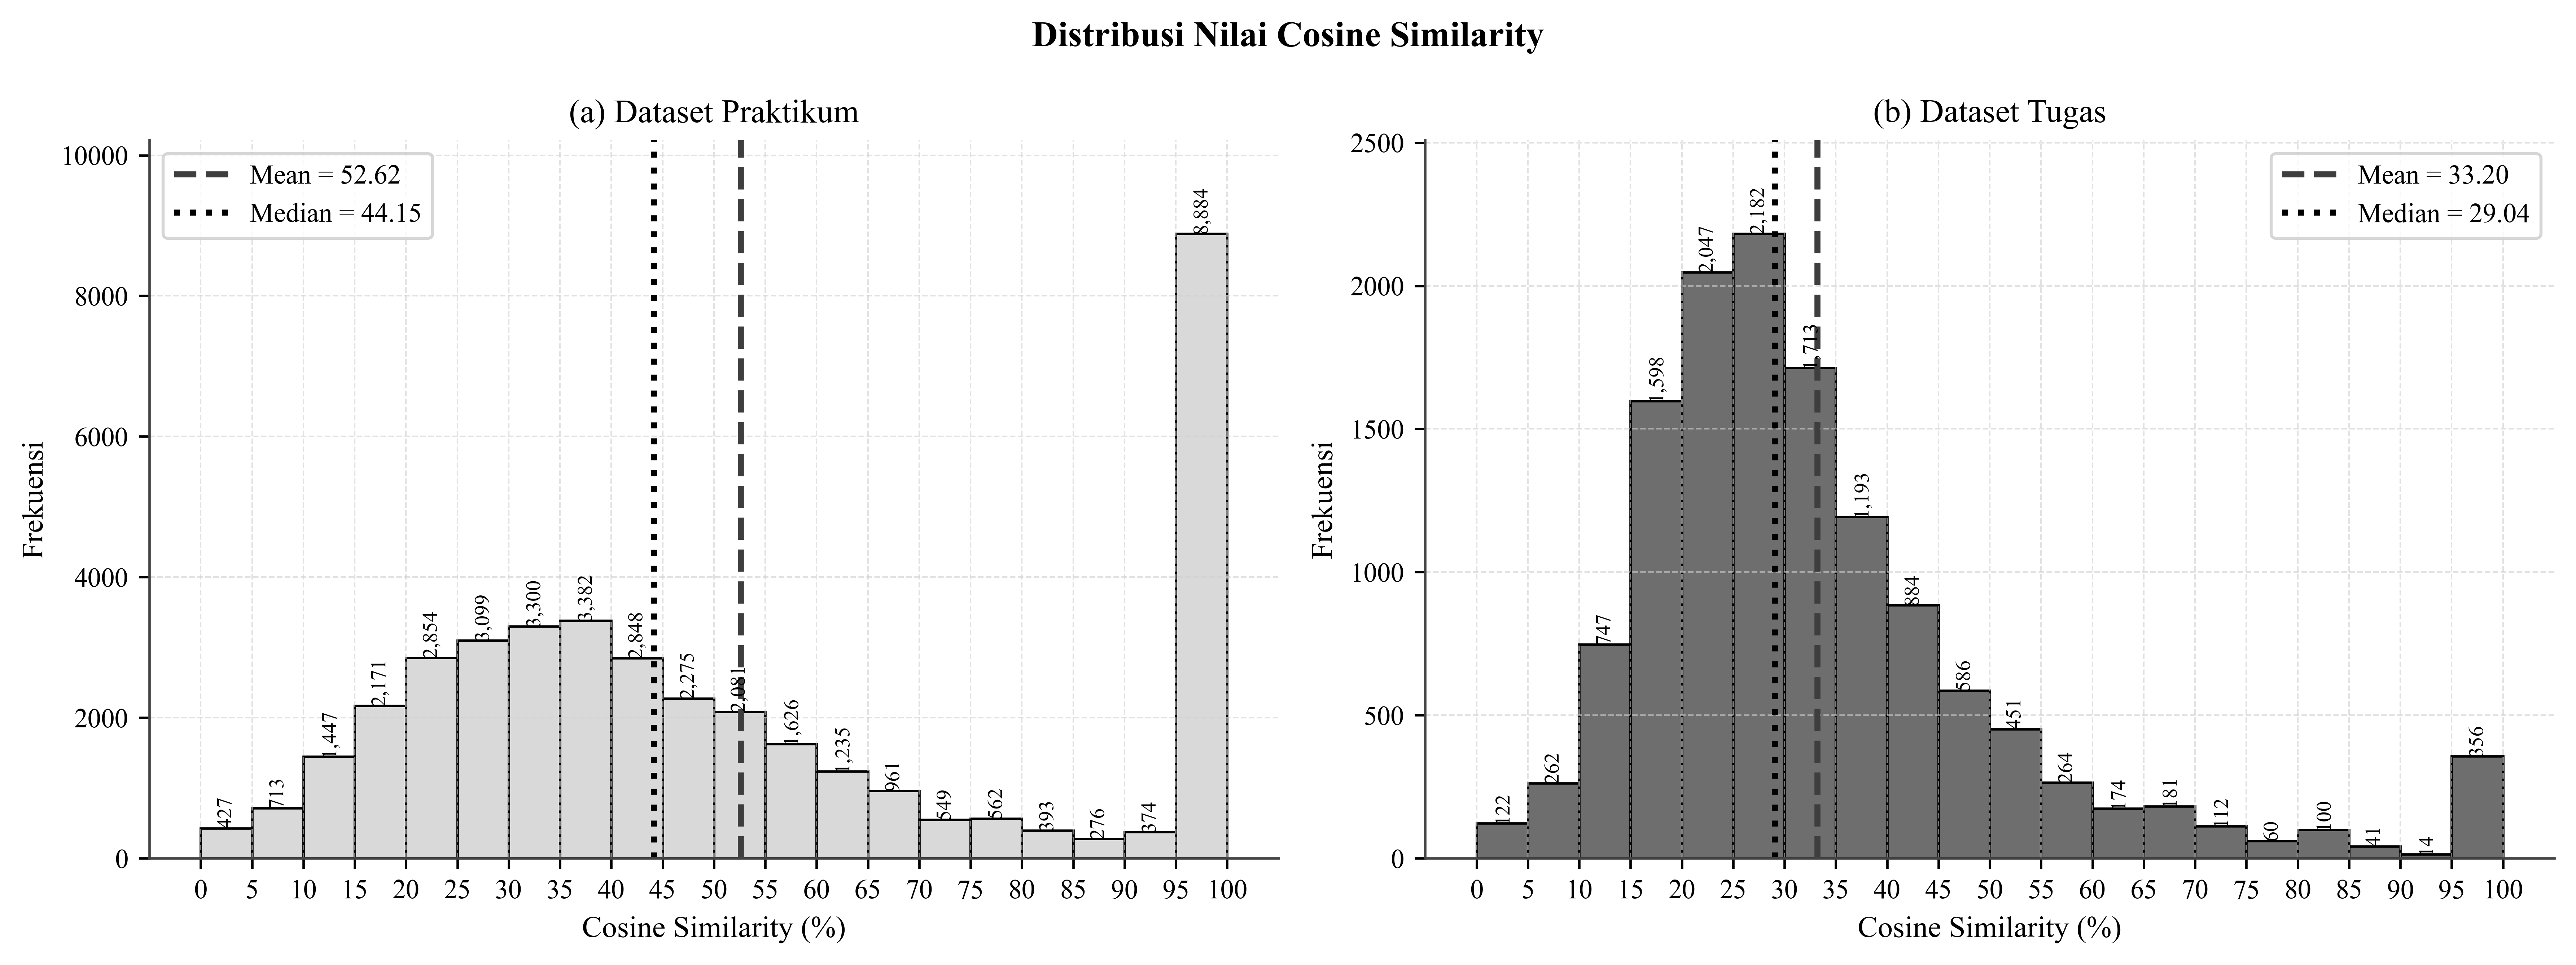

In [7]:
# =============================================================================
# GAMBAR 5.xx DISTRIBUSI COSINE SIMILARITY
# =============================================================================

# =============================================================================
# LOAD DATA
# =============================================================================

df_prak = pd.read_excel(
    FILE_PRAK,
    sheet_name="all_similarity"
)

df_tgs = pd.read_excel(
    FILE_TGS,
    sheet_name="all_similarity"
)

# =============================================================================
# DATA
# =============================================================================

prak_scores = df_prak["similarity_score"]
tgs_scores  = df_tgs["similarity_score"]

# =============================================================================
# BINNING
# =============================================================================

BIN_WIDTH = 5

bins = np.arange(
    0,
    100 + BIN_WIDTH,
    BIN_WIDTH
)

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    dpi=DPI
)

# =============================================================================
# PRAKTIKUM
# =============================================================================

counts, edges, patches = axes[0].hist(
    prak_scores,
    bins=bins,
    color=COLOR_MAIN,
    edgecolor="black",
    linewidth=0.8
)

# Label frekuensi
for count, patch in zip(counts, patches):
    if count > 0:
        axes[0].annotate(
            f"{int(count):,}",

            (
                patch.get_x() + patch.get_width()/2,
                count
            ),

            ha="center",
            va="bottom",

            fontsize=7,
            rotation=90
        )

# Mean
axes[0].axvline(
    prak_scores.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {prak_scores.mean():.2f}"
)

# Median
axes[0].axvline(
    prak_scores.median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {prak_scores.median():.2f}"
)
axes[0].set_ylim(
    0,
    max(counts) * 1.15
)

axes[0].set_title("(a) Dataset Praktikum")
axes[0].set_xlabel("Cosine Similarity (%)")
axes[0].set_ylabel("Frekuensi")

axes[0].set_xticks(bins)
axes[0].legend()

# =============================================================================
# TUGAS
# =============================================================================

counts, edges, patches = axes[1].hist(
    tgs_scores,
    bins=bins,
    color=COLOR_SECOND,
    edgecolor="black",
    linewidth=0.8
)

# Label frekuensi
for count, patch in zip(counts, patches):
    if count > 0:
        axes[1].annotate(
            f"{int(count):,}",

            (
                patch.get_x() + patch.get_width()/2,
                count
            ),

            ha="center",
            va="bottom",

            fontsize=7,
            rotation=90
        )

# Mean
axes[1].axvline(
    tgs_scores.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {tgs_scores.mean():.2f}"
)

# Median
axes[1].axvline(
    tgs_scores.median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {tgs_scores.median():.2f}"
)

axes[1].set_ylim(
    0,
    max(counts) * 1.15
)

axes[1].set_title("(b) Dataset Tugas")
axes[1].set_xlabel("Cosine Similarity (%)")
axes[1].set_ylabel("Frekuensi")

axes[1].set_xticks(bins)
axes[1].legend()

# =============================================================================
# TITLE
# =============================================================================

fig.suptitle(
    "Distribusi Nilai Cosine Similarity",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

# =============================================================================
# SAVE
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Gambar_Distribusi_Cosine_Similarity.png"
    ),
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

In [9]:
# =============================================================================
# RATA-RATA SKOR KEMIRIPAN PER MODUL
# =============================================================================
df_prak = pd.read_excel(
    FILE_PRAK,
    sheet_name="all_similarity"
)

df_tgs = pd.read_excel(
    FILE_TGS,
    sheet_name="all_similarity"
)

MODULE_COL = "modul"
SCORE_COL = "similarity_score"

# =============================================================================
# MEAN PER MODUL
# =============================================================================

mean_prak = (
    df_prak
    .groupby(MODULE_COL)[SCORE_COL]
    .mean()
    .rename("Praktikum")
)

mean_tgs = (
    df_tgs
    .groupby(MODULE_COL)[SCORE_COL]
    .mean()
    .rename("Tugas")
)

table_similarity = pd.concat(
    [mean_prak, mean_tgs],
    axis=1
)

table_similarity = (
    table_similarity
    .reset_index()
    .rename(columns={
        MODULE_COL: "Modul"
    })
)

table_similarity["Total"] = (
    table_similarity["Praktikum"].fillna(0)
    + table_similarity["Tugas"].fillna(0)
)

table_similarity = table_similarity.round(2)

display(table_similarity)

,Modul,Praktikum,Tugas,Total
0,js02,52.55,38.56,91.11
1,js03,52.53,32.10,84.64
2,js04,50.55,27.52,78.07
3,js05,50.64,31.90,82.54
4,js06,52.71,30.85,83.56
5,js07,54.24,63.81,118.05
6,js09,55.62,30.38,86.00
7,js11,63.02,26.11,89.13
8,js13,36.26,36.44,72.70
9,js14,49.79,27.24,77.03


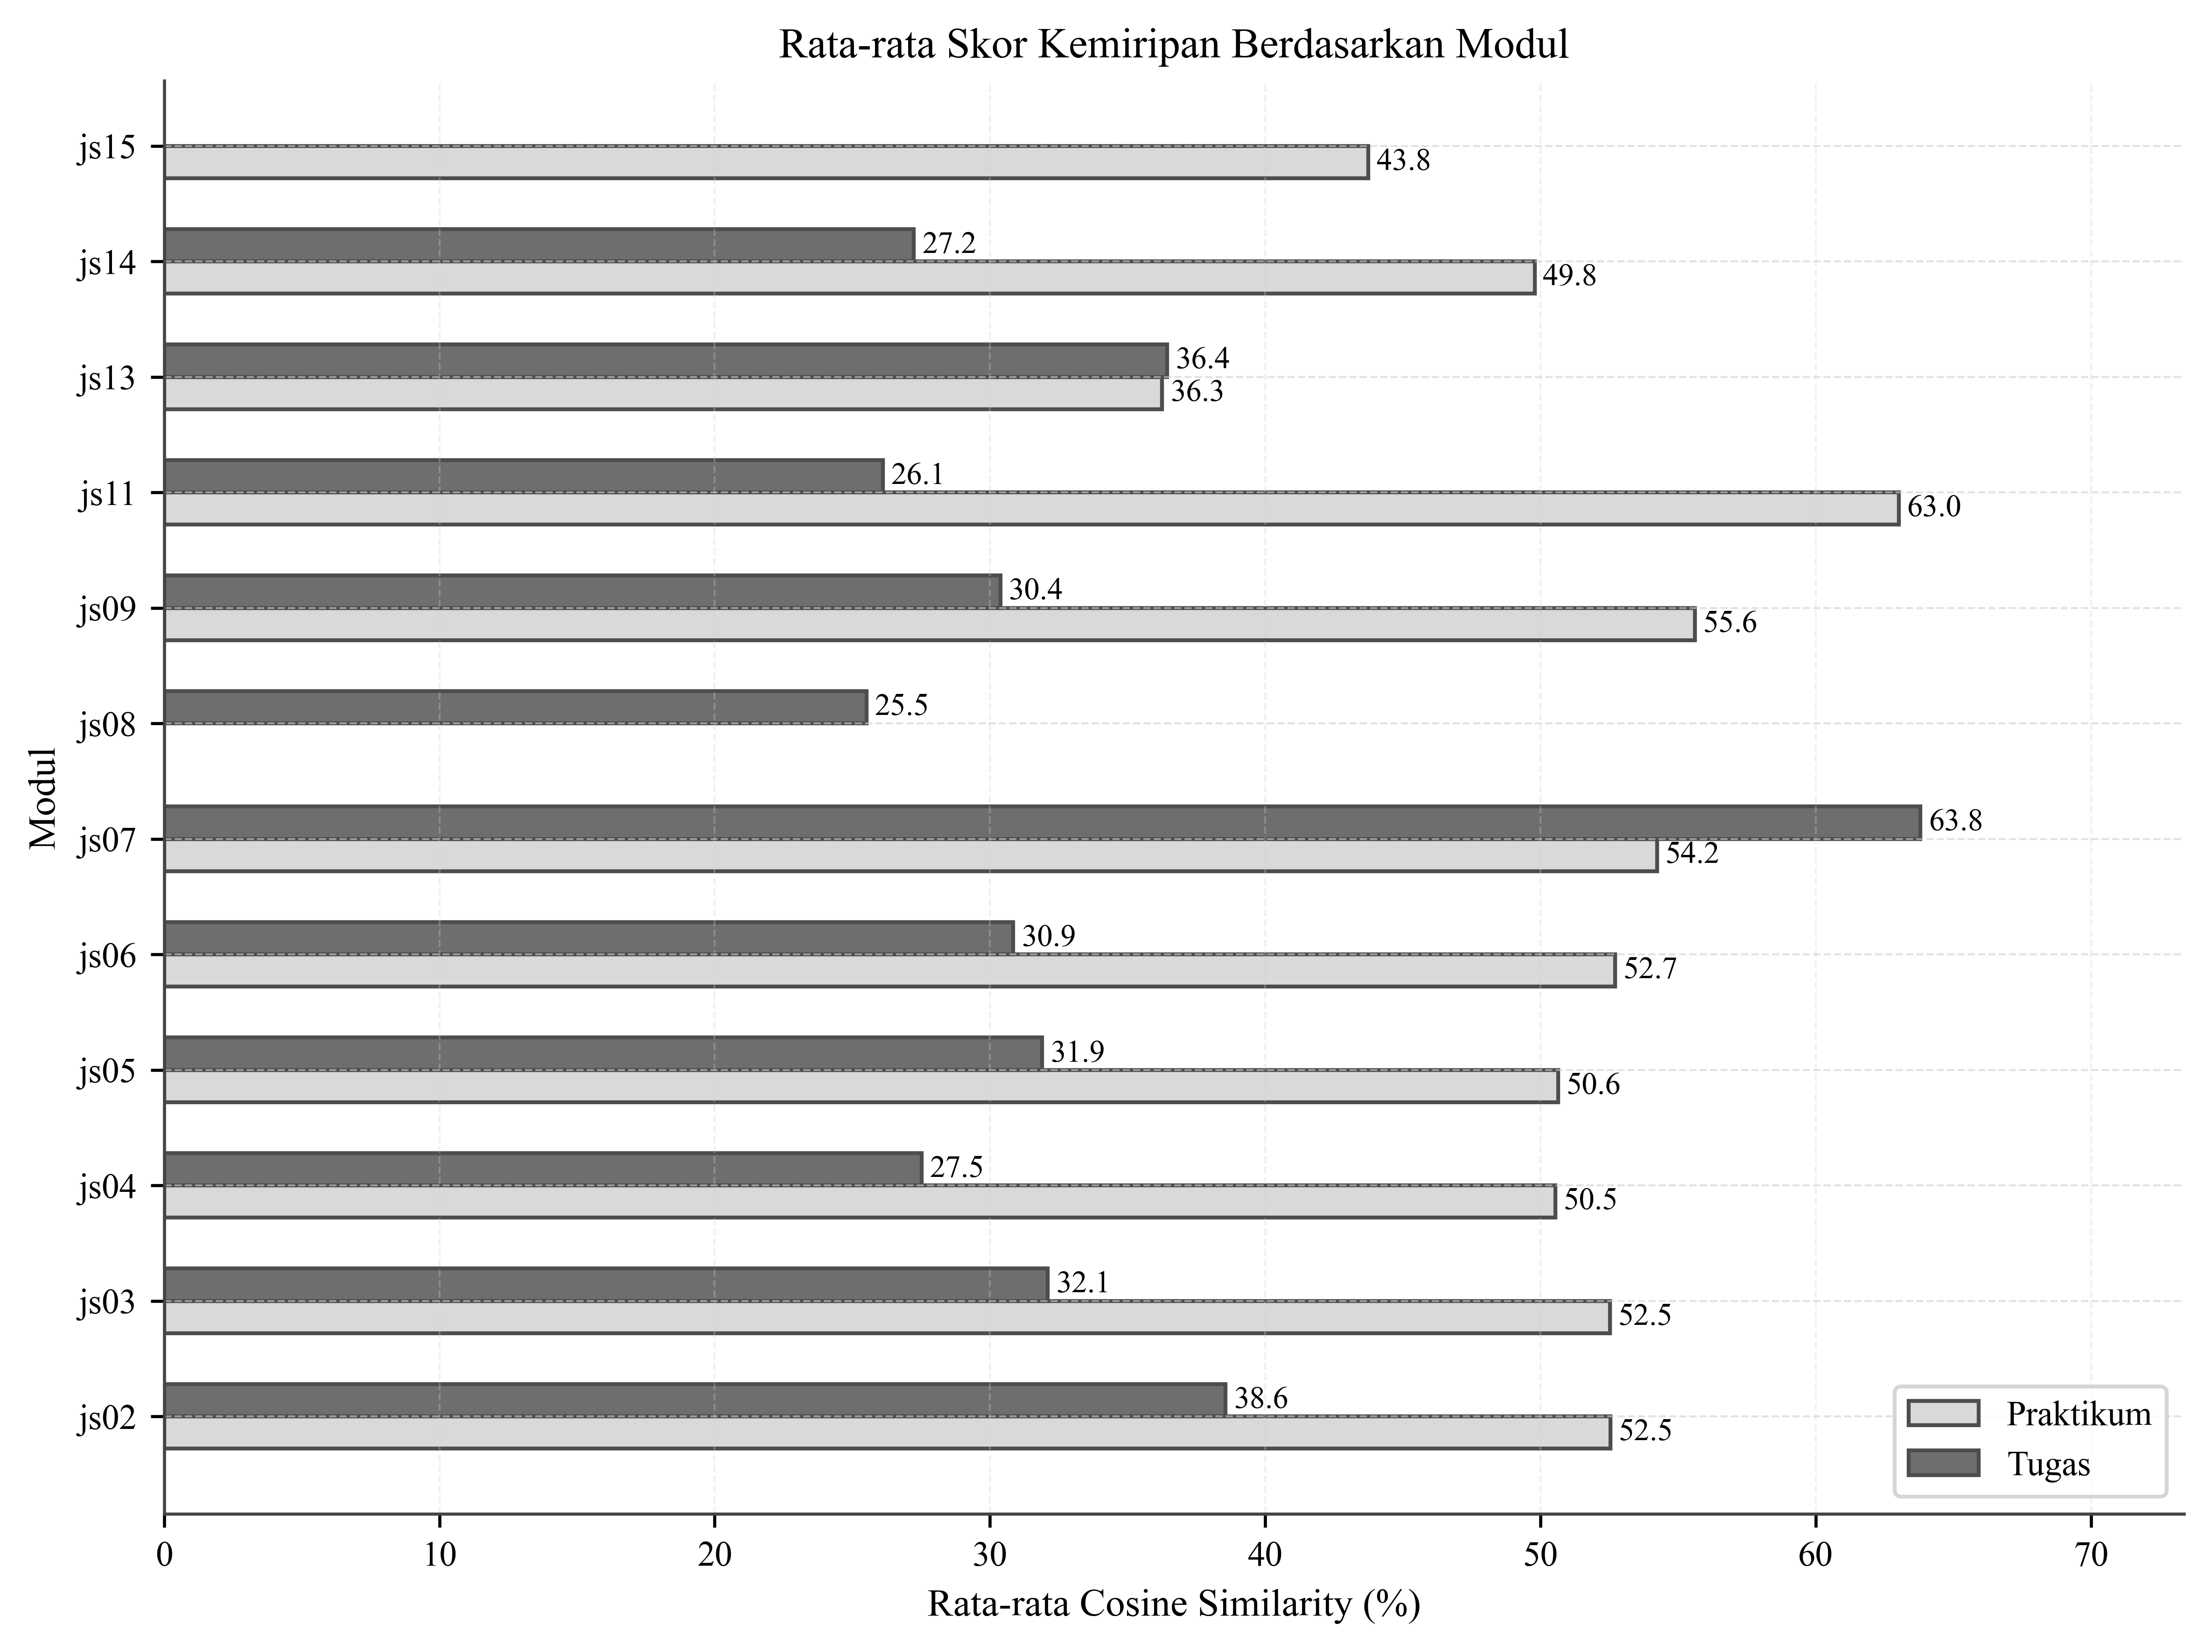

In [10]:
# =============================================================================
# GRAFIK RATA-RATA SKOR KEMIRIPAN PER MODUL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

plot_df = table_similarity.copy()

plot_df["modul_num"] = (
    plot_df["Modul"]
    .str.extract(r"(\d+)")
    .astype(int)
)

plot_df = (
    plot_df
    .sort_values("modul_num")
    .drop(columns="modul_num")
)

y = np.arange(len(plot_df))

bar_height = 0.28

fig, ax = plt.subplots(
    figsize=(8, 6),
    dpi=DPI
)

# -----------------------------------------------------------------------------
# PRAKTIKUM
# -----------------------------------------------------------------------------

bars_prak = ax.barh(
    y - bar_height/2,

    plot_df["Praktikum"],

    height=bar_height,

    color=COLOR_MAIN,
    edgecolor="#4D4D4D",

    label="Praktikum"
)

# -----------------------------------------------------------------------------
# TUGAS
# -----------------------------------------------------------------------------

bars_tgs = ax.barh(
    y + bar_height/2,

    plot_df["Tugas"],

    height=bar_height,

    color=COLOR_SECOND,
    edgecolor="#4D4D4D",

    label="Tugas"
)

# -----------------------------------------------------------------------------
# LABEL NILAI
# -----------------------------------------------------------------------------

for bar in bars_prak:

    width = bar.get_width()

    if not np.isnan(width):

        ax.text(
            width + 0.3,
            bar.get_y() + bar.get_height()/2,

            f"{width:.1f}",

            va="center",
            fontsize=8
        )

for bar in bars_tgs:

    width = bar.get_width()

    if not np.isnan(width):

        ax.text(
            width + 0.3,
            bar.get_y() + bar.get_height()/2,

            f"{width:.1f}",

            va="center",
            fontsize=8
        )

# -----------------------------------------------------------------------------
# AXIS
# -----------------------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["Modul"]
)

ax.set_xlabel(
    "Rata-rata Cosine Similarity (%)"
)

ax.set_ylabel(
    "Modul"
)

ax.set_title(
    "Rata-rata Skor Kemiripan Berdasarkan Modul"
)

ax.legend()

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# -----------------------------------------------------------------------------
# LIMIT
# -----------------------------------------------------------------------------

ax.set_xlim(
    0,
    max(
        plot_df["Praktikum"].max(),
        plot_df["Tugas"].max()
    ) * 1.15
)

plt.tight_layout()

# -----------------------------------------------------------------------------
# SAVE
# -----------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Gambar_Rata_Rata_Cosine_Per_Modul.png"
    ),
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

In [11]:
# =============================================================================
# TABEL 5.16 REKAPITULASI INDIKASI KLON DATASET PRAKTIKUM
# =============================================================================

import pandas as pd

FILE_PRAK = "output(2)/11_similarity_report_prak.xlsx"

# =============================================================================
# TABEL 5.16 REKAPITULASI INDIKASI KLON DATASET PRAKTIKUM
# =============================================================================

df = pd.read_excel(
    FILE_PRAK,
    sheet_name="all_similarity"
)

MODULE_COL = "modul"
CATEGORY_COL = "kategori"

summary = []

for modul, group in df.groupby(MODULE_COL):

    total = len(group)

    clone = (
        group[CATEGORY_COL]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TERINDIKASI KLON")
        .sum()
    )

    non_clone = (
        group[CATEGORY_COL]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TIDAK TERINDIKASI KLON")
        .sum()
    )

    persen = (
        clone / total * 100
        if total > 0 else 0
    )

    summary.append([
        modul.upper(),
        total,
        clone,
        non_clone,
        round(persen, 2)
    ])

table_516 = pd.DataFrame(
    summary,
    columns=[
        "Modul",
        "Total Pasangan",
        "Terindikasi Klon",
        "Tidak Terindikasi",
        "Persentase Klon (%)"
    ]
)

# =============================================================================
# TOTAL
# =============================================================================

total_pasangan = table_516["Total Pasangan"].sum()
total_klon = table_516["Terindikasi Klon"].sum()
total_non = table_516["Tidak Terindikasi"].sum()

table_516.loc[len(table_516)] = [
    "TOTAL",
    total_pasangan,
    total_klon,
    total_non,
    round(
        total_klon / total_pasangan * 100,
        2
    )
]

with pd.ExcelWriter(
    FILE_PRAK,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    table_516.to_excel(
        writer,
        sheet_name="rekap_kategori_klon",
        index=False
    )
autofit_workbook(FILE_PRAK)
display(table_516)

,Modul,Total Pasangan,Terindikasi Klon,Tidak Terindikasi,Persentase Klon (%)
0,JS02,4854,957,3897,19.72
1,JS03,4763,1334,3429,28.01
2,JS04,3243,663,2580,20.44
3,JS05,2211,690,1521,31.21
4,JS06,2356,343,2013,14.56
5,JS07,6264,1822,4442,29.09
6,JS09,3480,1032,2448,29.66
7,JS11,5881,2350,3531,39.96
8,JS13,3434,58,3376,1.69
9,JS14,2025,481,1544,23.75


In [12]:
# =============================================================================
# TABEL 5.16 REKAPITULASI INDIKASI KLON DATASET TUGAS
# =============================================================================

import pandas as pd

FILE_TGS = "output(2)/11_similarity_report_tgs.xlsx"

# =============================================================================
# TABEL 5.16 REKAPITULASI INDIKASI KLON DATASET TUGAS
# =============================================================================

df = pd.read_excel(
    FILE_TGS,
    sheet_name="all_similarity"
)

MODULE_COL = "modul"
CATEGORY_COL = "kategori"

summary = []

for modul, group in df.groupby(MODULE_COL):

    total = len(group)

    clone = (
        group[CATEGORY_COL]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TERINDIKASI KLON")
        .sum()
    )

    non_clone = (
        group[CATEGORY_COL]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TIDAK TERINDIKASI KLON")
        .sum()
    )

    persen = (
        clone / total * 100
        if total > 0 else 0
    )

    summary.append([
        modul.upper(),
        total,
        clone,
        non_clone,
        round(persen, 2)
    ])

table_517 = pd.DataFrame(
    summary,
    columns=[
        "Modul",
        "Total Pasangan",
        "Terindikasi Klon",
        "Tidak Terindikasi",
        "Persentase Klon (%)"
    ]
)

# =============================================================================
# TOTAL
# =============================================================================

total_pasangan = table_517["Total Pasangan"].sum()
total_klon = table_517["Terindikasi Klon"].sum()
total_non = table_517["Tidak Terindikasi"].sum()

table_517.loc[len(table_517)] = [
    "TOTAL",
    total_pasangan,
    total_klon,
    total_non,
    round(
        total_klon / total_pasangan * 100,
        2
    )
]

with pd.ExcelWriter(
    FILE_TGS,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    table_517.to_excel(
        writer,
        sheet_name="rekap_kategori_klon",
        index=False
    )
autofit_workbook(FILE_TGS)
display(table_517)

,Modul,Total Pasangan,Terindikasi Klon,Tidak Terindikasi,Persentase Klon (%)
0,JS02,1176,25,1151,2.13
1,JS03,1176,15,1161,1.28
2,JS04,990,10,980,1.01
3,JS05,1128,26,1102,2.30
4,JS06,1035,10,1025,0.97
5,JS07,946,369,577,39.01
6,JS08,1081,5,1076,0.46
7,JS09,2352,24,2328,1.02
8,JS11,1081,16,1065,1.48
9,JS13,1176,7,1169,0.60


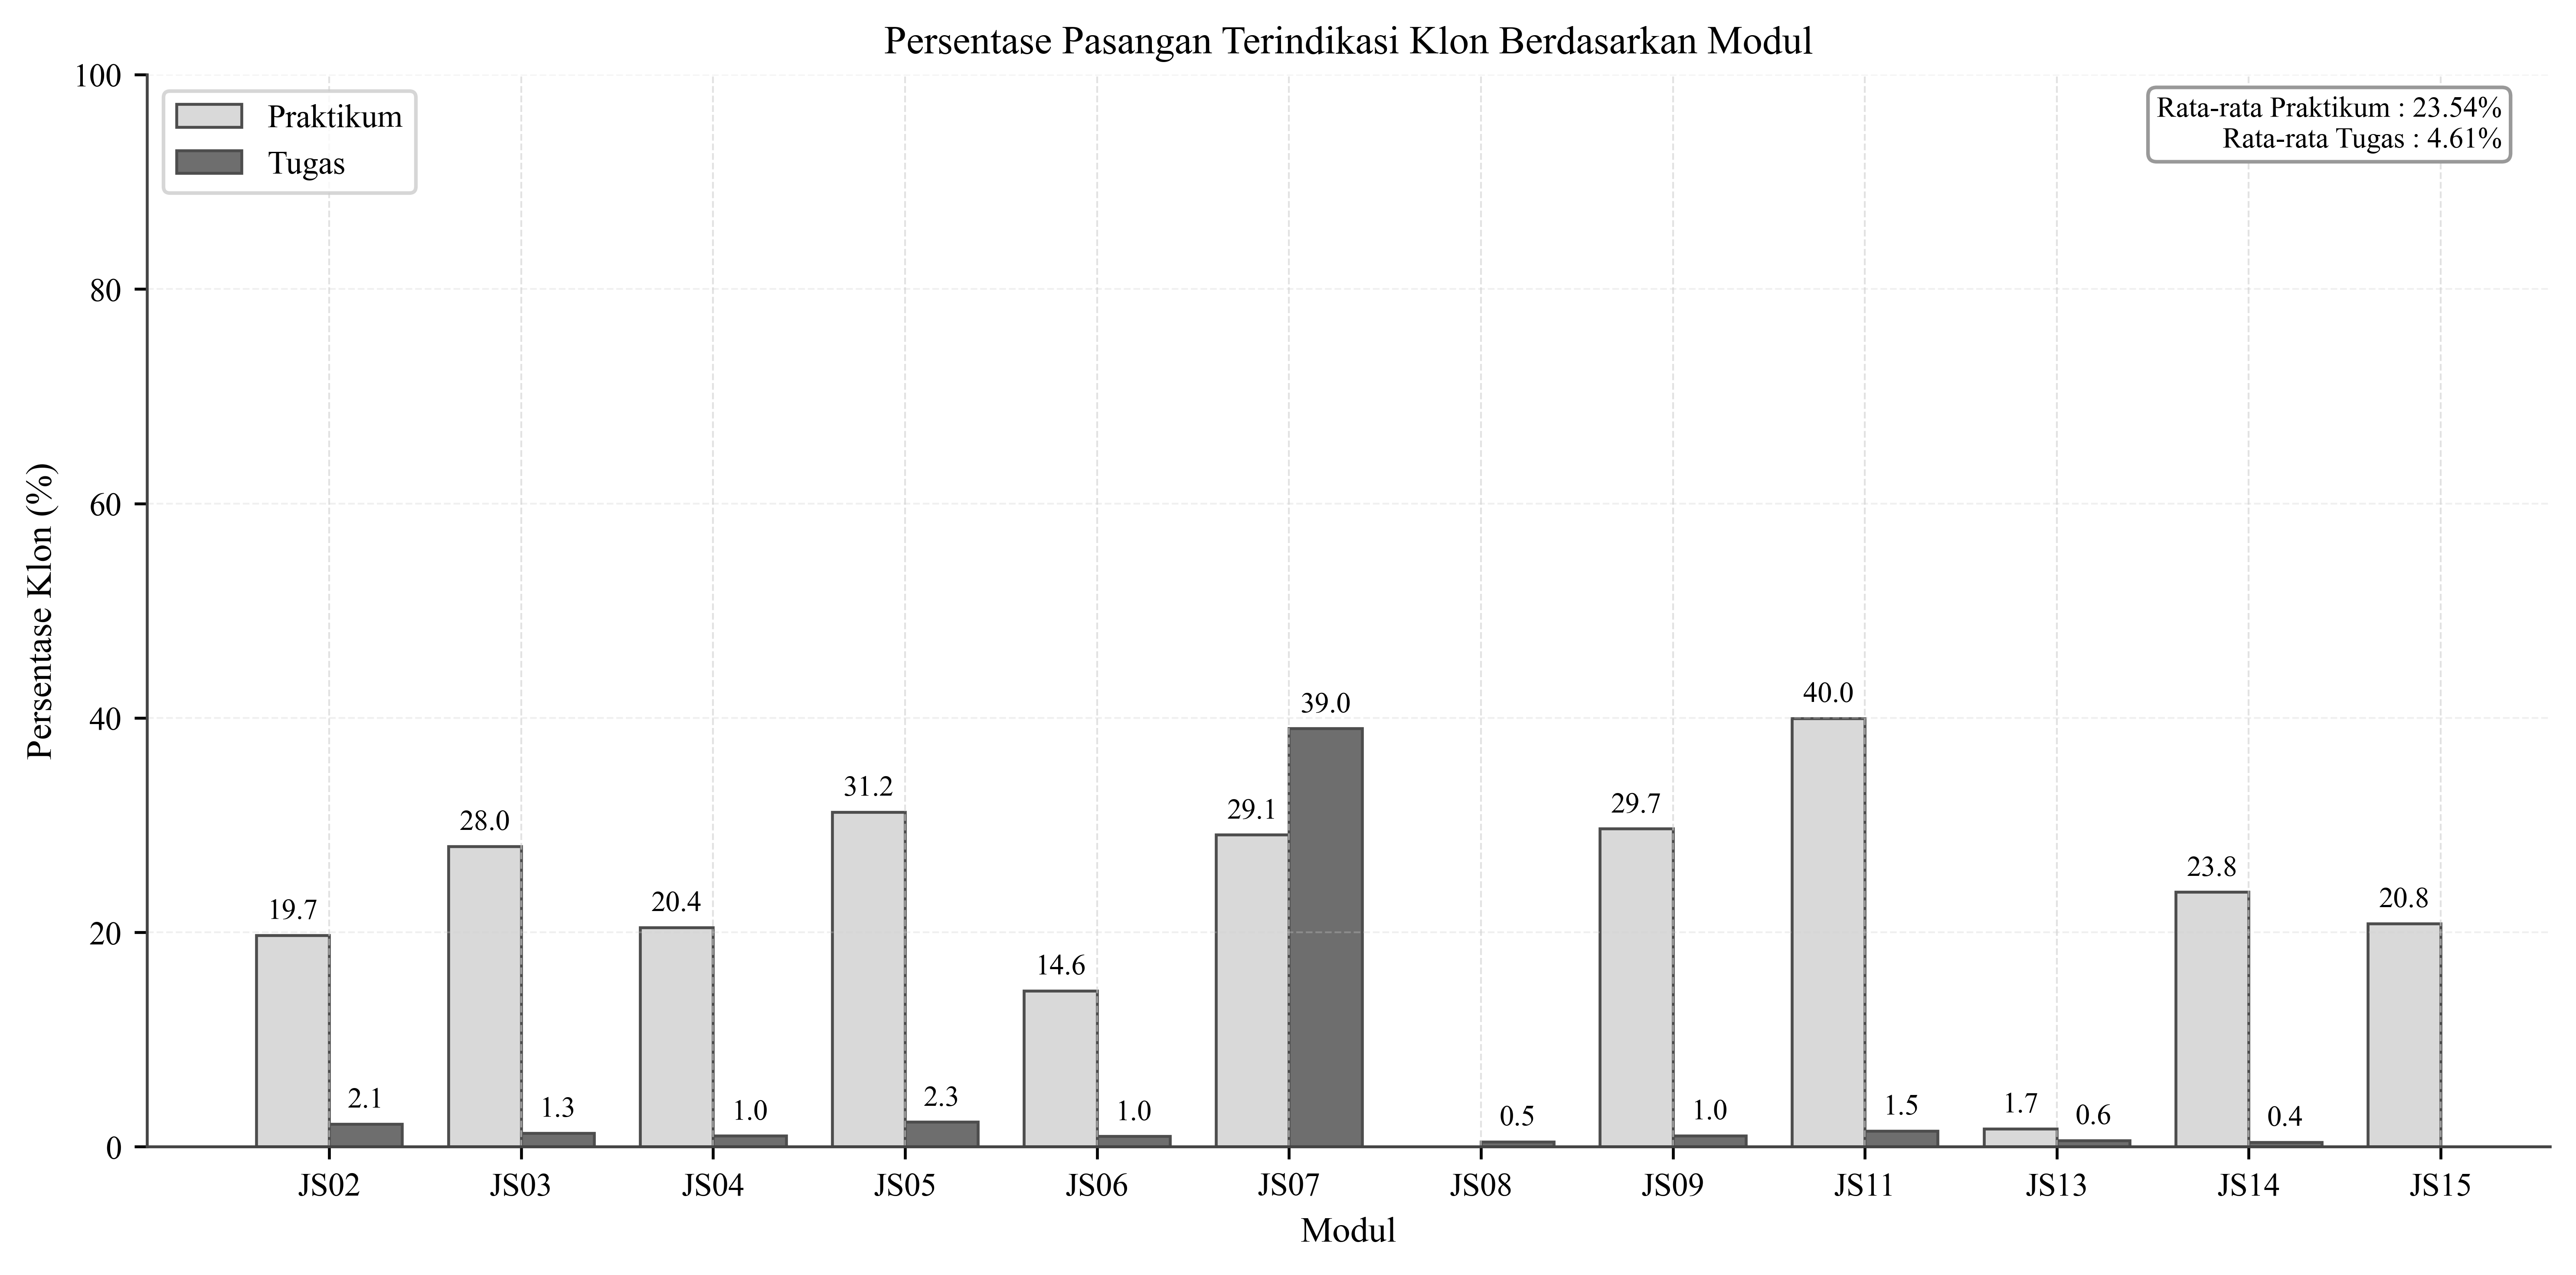

In [13]:
# =============================================================================
# GAMBAR 5.11
# PERSENTASE PASANGAN TERINDIKASI KLON BERDASARKAN MODUL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PREPARE DATA
# =============================================================================

plot_df = pd.merge(
    table_516[
        ["Modul", "Persentase Klon (%)"]
    ].rename(
        columns={
            "Persentase Klon (%)": "Praktikum"
        }
    ),

    table_517[
        ["Modul", "Persentase Klon (%)"]
    ].rename(
        columns={
            "Persentase Klon (%)": "Tugas"
        }
    ),

    on="Modul",
    how="outer"
)

# hapus baris TOTAL
plot_df = plot_df[
    plot_df["Modul"] != "TOTAL"
].copy()

# urutkan modul secara numerik
plot_df["modul_num"] = (
    plot_df["Modul"]
    .str.extract(r"(\d+)")
    .astype(int)
)

plot_df = (
    plot_df
    .sort_values("modul_num")
    .drop(columns="modul_num")
)

# =============================================================================
# FIGURE
# =============================================================================

x = np.arange(len(plot_df))

bar_width = 0.38

fig, ax = plt.subplots(
    figsize=(10, 5),
    dpi=DPI
)

# =============================================================================
# PRAKTIKUM
# =============================================================================

bars_prak = ax.bar(
    x - bar_width/2,

    plot_df["Praktikum"],

    width=bar_width,

    color=COLOR_MAIN,
    edgecolor="#4D4D4D",
    linewidth=0.8,

    label="Praktikum"
)

# =============================================================================
# TUGAS
# =============================================================================

bars_tgs = ax.bar(
    x + bar_width/2,

    plot_df["Tugas"],

    width=bar_width,

    color=COLOR_SECOND,
    edgecolor="#4D4D4D",
    linewidth=0.8,

    label="Tugas"
)

# =============================================================================
# LABEL PERSENTASE
# =============================================================================

for bar in bars_prak:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,

        f"{height:.1f}",

        ha="center",
        va="bottom",

        fontsize=8
    )

for bar in bars_tgs:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,

        f"{height:.1f}",

        ha="center",
        va="bottom",

        fontsize=8
    )

# =============================================================================
# AXES
# =============================================================================

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["Modul"]
)

ax.set_xlabel(
    "Modul"
)

ax.set_ylabel(
    "Persentase Klon (%)"
)

ax.set_title(
    "Persentase Pasangan Terindikasi Klon Berdasarkan Modul"
)

ax.set_ylim(0, 100)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# =============================================================================
# INFO BOX
# =============================================================================

mean_prak = plot_df["Praktikum"].mean()
mean_tgs = plot_df["Tugas"].mean()

ax.text(
    0.98,
    0.98,

    f"Rata-rata Praktikum : {mean_prak:.2f}%\n"
    f"Rata-rata Tugas : {mean_tgs:.2f}%",

    transform=ax.transAxes,

    ha="right",
    va="top",

    fontsize=8,

    bbox=dict(
        facecolor="white",
        edgecolor="#999999",
        boxstyle="round,pad=0.3"
    )
)

plt.tight_layout()

# =============================================================================
# SAVE
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Gambar_5_11_Persentase_Klon_Per_Modul.png"
    ),
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

# Eval

In [8]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

FILE_EVAL_TUGAS = "output(2)/eval/tugas/evaluasi_cosine.xlsx"
df_eval_tgs = pd.read_excel(
    FILE_EVAL_TUGAS,
    sheet_name="pairs_prediction_log"
)

results = []

for clone_type, group in df_eval_tgs.groupby("clone_type"):

    y_true = group["ground_truth"]
    y_pred = group["prediction"]

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    results.append({
        "Clone Type": clone_type,
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2)
    })

table_clone_metrics = pd.DataFrame(results)

display(table_clone_metrics)

,Clone Type,Precision (%),Recall (%),F1-Score (%)
0,negative,0.0,0.00,0.00
1,type1,100.0,100.00,100.00
2,type2,100.0,100.00,100.00
3,type3,100.0,14.12,24.74
4,type4,100.0,0.59,1.17


## perbandingan jplag

In [1]:
COSINE_PRAK = "output(2)/eval/praktikum/evaluasi_cosine.xlsx"
COSINE_TGS  = "output(2)/eval/tugas/evaluasi_cosine.xlsx"

JPLAG_PRAK  = "output(2)/eval/praktikum/evaluasi_jplag.xlsx"
JPLAG_TGS   = "output(2)/eval/tugas/evaluasi_jplag.xlsx"

,Dataset,Graph2Vec + AST,JPlag
0,Praktikum,71.81,68.79
1,Tugas,77.48,68.22


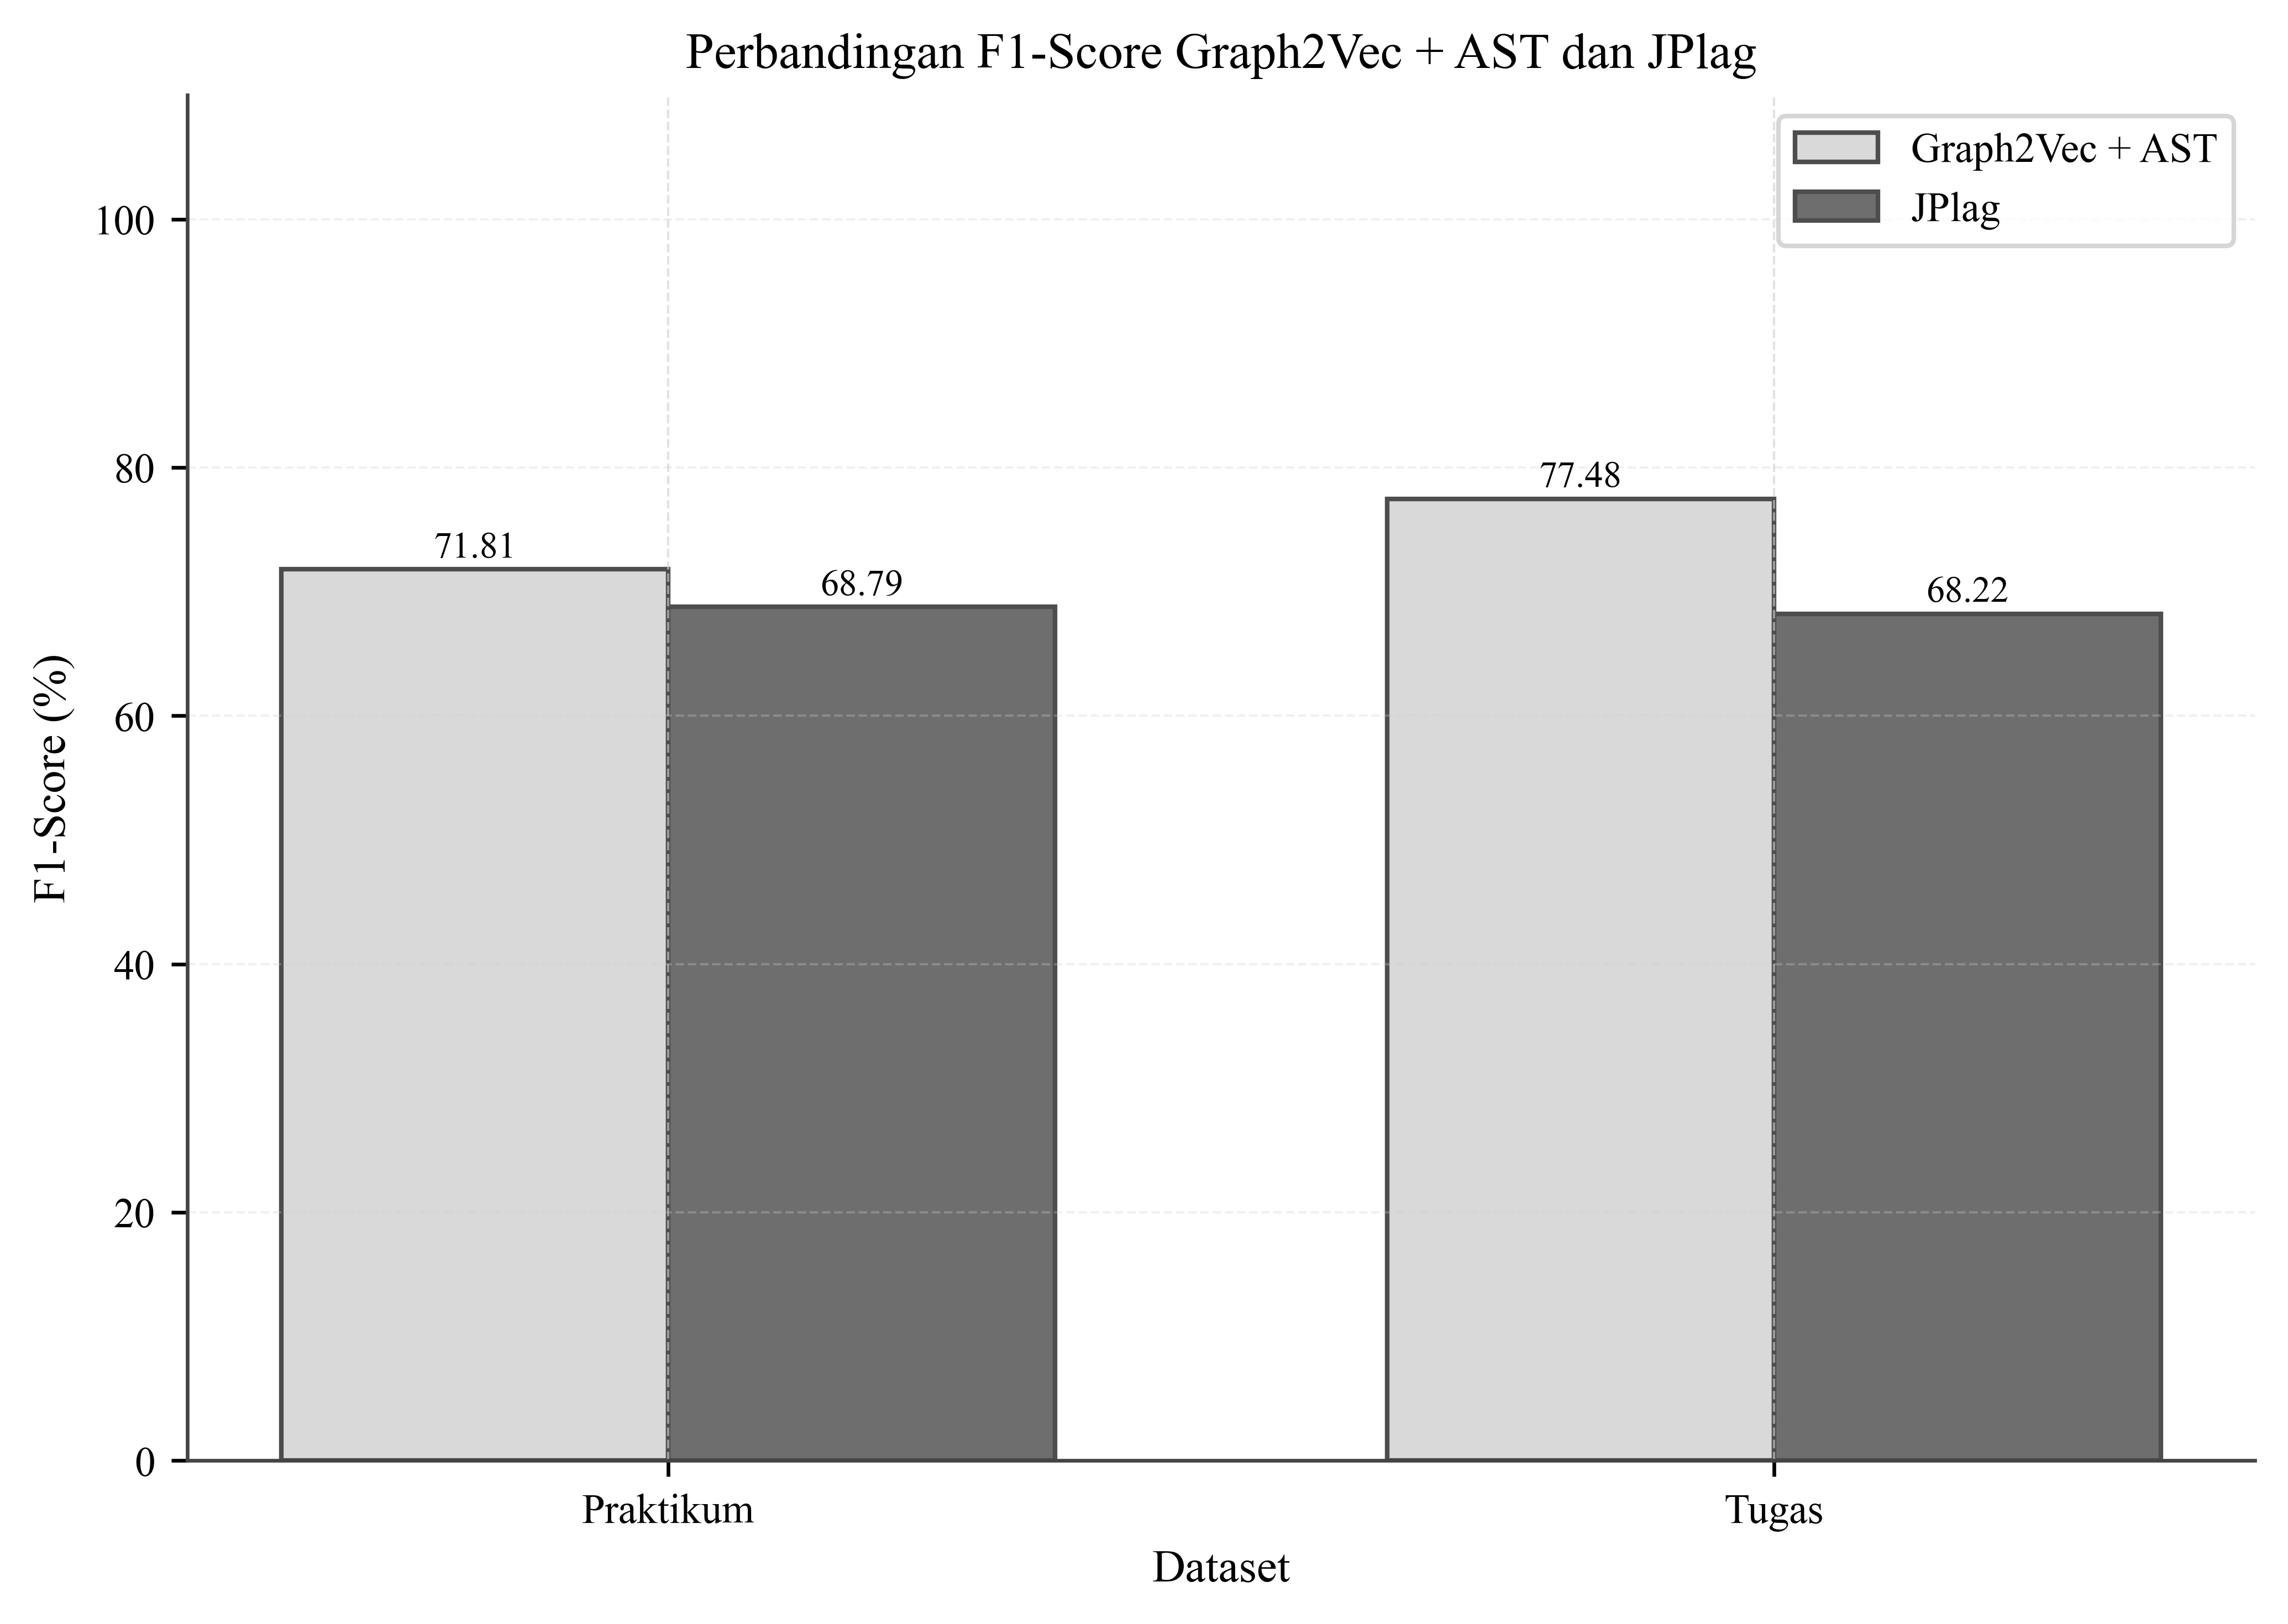

In [6]:
# =============================================================================
# LOAD F1 SCORE
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_f1_score(file_path):

    df = pd.read_excel(
        file_path,
        sheet_name="metrics_summary"
    )

    if "F1_Score" in df.columns:
        f1 = df.loc[0, "F1_Score"]
    else:
        f1 = df.loc[0, "F1 Score (%)"]

    # hilangkan tanda %
    if isinstance(f1, str):
        f1 = f1.replace("%", "").replace(",", ".")

    return float(f1)

# =============================================================================
# F1 VALUES
# =============================================================================

f1_graph_prak = get_f1_score(COSINE_PRAK)
f1_graph_tgs  = get_f1_score(COSINE_TGS)

f1_jplag_prak = get_f1_score(JPLAG_PRAK)
f1_jplag_tgs  = get_f1_score(JPLAG_TGS)

# =============================================================================
# DATAFRAME
# =============================================================================

plot_df = pd.DataFrame({

    "Dataset": [
        "Praktikum",
        "Tugas"
    ],

    "Graph2Vec + AST": [
        f1_graph_prak,
        f1_graph_tgs
    ],

    "JPlag": [
        f1_jplag_prak,
        f1_jplag_tgs
    ]
})

display(plot_df)

# =============================================================================
# BAR CHART
# =============================================================================

x = np.arange(len(plot_df))

width = 0.35

fig, ax = plt.subplots(
    figsize=(7,5),
    dpi=DPI
)

bars_graph = ax.bar(
    x - width/2,

    plot_df["Graph2Vec + AST"],

    width,

    color=COLOR_MAIN,
    edgecolor="#4D4D4D",

    label="Graph2Vec + AST"
)

bars_jplag = ax.bar(
    x + width/2,

    plot_df["JPlag"],

    width,

    color=COLOR_SECOND,
    edgecolor="#4D4D4D",

    label="JPlag"
)

# =============================================================================
# LABEL
# =============================================================================

for bar in bars_graph:

    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,

        f"{h:.2f}",

        ha="center",
        fontsize=8
    )

for bar in bars_jplag:

    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,

        f"{h:.2f}",

        ha="center",
        fontsize=8
    )

# =============================================================================
# AXES
# =============================================================================

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["Dataset"]
)

ax.set_ylabel(
    "F1-Score (%)"
)

ax.set_xlabel(
    "Dataset"
)

ax.set_title(
    "Perbandingan F1-Score Graph2Vec + AST dan JPlag"
)

ax.set_ylim(0, 110)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Gambar_Perbandingan_F1_Graph2Vec_vs_JPlag.png"
    ),
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ==============================================================================
# SCATTER PLOT GRAPH2VEC vs JPLAG (REUSABLE)
# ==============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_similarity_scatter(
    graph_file, jplag_file, merge_keys, title, output_name,
    graph_sheet="all_similarity", jplag_sheet="all_similarity",
    graph_similarity_col="similarity_score", jplag_similarity_col="similarity_score"
):
    """Scatter Plot perbandingan kemiripan Graph2Vec vs JPlag."""
    
    # LOAD & MERGE
    graph = pd.read_excel(graph_file, sheet_name=graph_sheet).rename(columns={graph_similarity_col: "graph_score"})
    jplag = pd.read_excel(jplag_file, sheet_name=jplag_sheet).rename(columns={jplag_similarity_col: "jplag_score"})
    df = pd.merge(graph, jplag, on=merge_keys, how="inner")

    # CLEANING
    for col in ["graph_score", "jplag_score"]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace("%", "").str.replace(",", "."), errors="coerce")
    df = df.dropna(subset=["graph_score", "jplag_score"])

    # CORRELATION & PLOT
    corr = df["graph_score"].corr(df["jplag_score"])
    fig, ax = plt.subplots(figsize=(6.5, 6), dpi=DPI)

    ax.scatter(df["graph_score"], df["jplag_score"], s=18, color=COLOR_MAIN, edgecolor="#555555", linewidth=0.4, alpha=0.55)
    ax.plot([0, 100], [0, 100], linestyle="--", linewidth=2, color=COLOR_ACCENT, label="y = x")

    ax.text(0.03, 0.97, f"Pearson r = {corr:.3f}\nn = {len(df):,}", transform=ax.transAxes, 
            ha="left", va="top", fontsize=8, bbox=dict(facecolor="white", edgecolor="#999999", boxstyle="round,pad=0.3"))

    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xlabel("Graph2Vec + AST Similarity (%)")
    ax.set_ylabel("JPlag Similarity (%)")
    ax.set_title(title)
    ax.grid(linestyle="--", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, output_name), dpi=DPI, bbox_inches="tight")
    plt.show()

    print("=" * 60 + f"\n{title}\nJumlah pasangan : {len(df):,}\nPearson r       : {corr:.4f}\n" + "=" * 60)
    return df

In [26]:
FILE_GRAPH_PRAK = "output(2)/11_similarity_report_prak.xlsx"
FILE_GRAPH_TGS  = "output(2)/11_similarity_report_tgs.xlsx"

FILE_JPLAG_PRAK = "jplag/output_jplag_prak/jplag_similarity_report.xlsx"
FILE_JPLAG_TGS  = "jplag/output_jplag_tgs/jplag_similarity_report.xlsx"

merge_keys = [
    "modul",
    "file",
    "nim1",
    "nim2",
]
plot_similarity_scatter(
    graph_file=FILE_GRAPH_PRAK,
    jplag_file=FILE_JPLAG_PRAK,
    merge_keys=merge_keys,
    title="Perbandingan Skor Similarity\nGraph2Vec + AST vs JPlag (Praktikum)",
    output_name="Scatter_Praktikum.png"
)

KeyError: 'nim1'